# Лабораторная работа 12. Отравление данных и атаки на приватность
## Стрельченко Алексей Александрович

Курс «Глубокое обучение и безопасность нейронных сетей». Уровень: бакалавриат, Python и основы PyTorch.

Все эксперименты выполняются на собственных локальных моделях, открытых цифрах 8×8 и синтетических векторах.
Нет внешних API, персональных данных, ключей или скачивания весов.

## План

| Блок | Эксперимент | Главный вопрос |
|---|---|---|
| A | Baseline и label flipping | Что меняется при повреждении меток? |
| B | Backdoor и контроль известного триггера | Может ли высокая clean accuracy скрывать уязвимость? |
| C | Membership inference, shadow calibration | Насколько loss выдаёт участие в обучении? |
| D | Model inversion | Восстановлен образ класса или конкретная запись? |
| E | Model extraction | Чем fidelity отличается от accuracy? |
| F | Выводы и воспроизводимость | Какие утверждения действительно подтверждены? |



Реализуйте 6 кодовых заданий (8 функций) и аналитическое задание F1. Заглушки возвращают None: зависимые опыты честно пропускаются, а не подменяются готовыми ответами.

In [22]:
# При необходимости выполните ОДИН РАЗ, затем перезапустите ядро:
# %pip install torch numpy scipy scikit-learn pandas matplotlib nbformat
import sys, time, copy, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
import sklearn
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, balanced_accuracy_score
from IPython.display import display

START = time.perf_counter()
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
print({"Python": platform.python_version(), "torch": torch.__version__,
       "numpy": np.__version__, "sklearn": sklearn.__version__, "device": DEVICE})

def tensor(x):
    return torch.as_tensor(x, dtype=torch.float32)

def new_model(d, k, seed=SEED, width=64):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(d, width), nn.ReLU(),
                         nn.Linear(width, width), nn.ReLU(), nn.Linear(width, k))

def fit(x, y, k=10, epochs=140, wd=1e-4, seed=SEED, width=64, soft=False):
    model = new_model(x.shape[1], k, seed, width)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=wd)
    xt = tensor(x)
    yt = tensor(y) if soft else torch.as_tensor(y, dtype=torch.long)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(xt)
        loss = -(yt * F.log_softmax(logits, dim=1)).sum(1).mean() if soft else F.cross_entropy(logits, yt)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return model.eval(), history

def probs(model, x):
    with torch.no_grad():
        return model(tensor(x)).softmax(1).numpy()

def acc(model, x, y):
    return accuracy_score(y, probs(model, x).argmax(1))

def pending(name):
    print(f"{name}: не выполнено. Реализуйте TODO и повторите Run All.")

results = {}

{'Python': '3.13.15', 'torch': '2.11.0+cpu', 'numpy': '2.1.3', 'sklearn': '1.6.1', 'device': 'cpu'}


## A. Данные и честный контроль

Digits из scikit-learn загружается локально и не требует сети. Делим исходные индексы ДО атак:
600 train, 197 validation, 500 public query pool, 500 test.
Чистый test не участвует в обучении и извлечении; pool не участвует в обучении teacher.
Параметры опытов заранее зафиксированы: не подбирайте их по итоговому test.
Данные public pool видит атакующий extraction, но его исходные метки в обучении клона не используются.

Отравление обучающих данных (data poisoning) — это атака, при которой злоумышленник контролирует часть тренировочного набора и модифицирует её так, чтобы итоговая модель вела себя враждебно. Простейший случай — label flipping: входные признаки не меняются, но часть меток заменяется на другие. Даже без «умной» оптимизации такая атака:

- ухудшает clean accuracy (граница решения «зашумляется»);

- при целевом сдвиге в один класс может создать targeted misclassification на инференсе.

Отличие от случайного шума разметки: при poisoning сдвиг систематический (например, всегда +1 mod k или всегда в конкретный класс), поэтому эффект накапливается, а не сглаживается.

Метрика качества здесь — обычная accuracy на чистом тесте, который в обучении не участвовал. Параметры (rate = 0, 0.1, 0.3) фиксируются заранее, чтобы не было «подгонки под итоговый test».

,train_accuracy,validation_accuracy,test_accuracy
0,1.0,0.954315,0.962


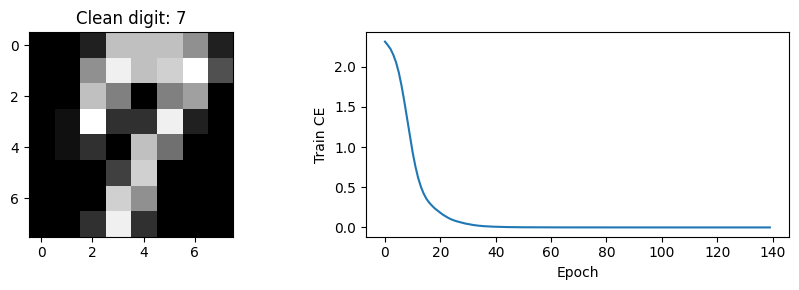

In [23]:
digits = load_digits()
X = (digits.data / 16.0).astype(np.float32)
y = digits.target
ids = np.arange(len(y))
rest, test_ids = train_test_split(ids, test_size=500, random_state=42, stratify=y)
rest, pool_ids = train_test_split(rest, test_size=500, random_state=43, stratify=y[rest])
train_ids, val_ids = train_test_split(rest, train_size=600, random_state=44, stratify=y[rest])
groups = [train_ids, val_ids, pool_ids, test_ids]
assert len(set(np.concatenate(groups))) == len(X)
for i in range(4):
    for j in range(i):
        assert not set(groups[i]) & set(groups[j])
Xtr, ytr = X[train_ids], y[train_ids]
Xval, yval = X[val_ids], y[val_ids]
Xpool = X[pool_ids]
Xte, yte = X[test_ids], y[test_ids]
clean, clean_hist = fit(Xtr, ytr)
baseline_acc = acc(clean, Xte, yte)
results["baseline"] = {"train_accuracy": acc(clean, Xtr, ytr),
                       "validation_accuracy": acc(clean, Xval, yval),
                       "test_accuracy": baseline_acc}
display(pd.DataFrame([results["baseline"]]))
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].imshow(Xtr[0].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
ax[0].set_title(f"Clean digit: {ytr[0]}")
ax[1].plot(clean_hist); ax[1].set(xlabel="Epoch", ylabel="Train CE")
plt.tight_layout(); plt.show()

### Задание A1. Label flipping 

Реализуйте изменение ровно `floor(rate * n)` меток без изменения входов и без изменения исходного массива.
Новая метка должна отличаться от старой. Сравните доли 0, 0.1, 0.3 при одинаковой инициализации модели.
Это простой baseline отравления, а не оптимизированная атака.

In [24]:
def flip_labels(y, rate, k, seed=42):
    """
    Испортить ровно floor(rate * n) меток, не меняя входы и не изменяя исходный массив.

    Параметры
    ---------
    y    : np.ndarray, shape (n,) — исходные метки классов (целые 0..k-1)
    rate : доля испорченных меток, float в [0, 1]
    k    : число классов
    seed : seed генератора для воспроизводимости выбора индексов и сдвигов

    Возвращает
    ----------
    yf      : копия y с изменёнными метками
    changed : индексы элементов, у которых метка изменена
    """
    y = np.asarray(y)
    n = len(y)

    # 1) Копия, чтобы не портить исходный массив.
    yf = y.copy()

    # 2) Сколько меток менять: floor(rate * n), как требует задание.
    n_change = int(np.floor(rate * n))
    if n_change == 0:
        return yf, np.array([], dtype=int)

    # 3) Свой RNG, чтобы результат зависел только от seed (детерминизм).
    rng = np.random.default_rng(seed)

    # 4) Выбор без возвращения: каждая запись портится не более одного раза.
    idx = rng.choice(n, size=n_change, replace=False)

    # 5) Ненулевой сдвиг по модулю k гарантирует, что новая метка ОТЛИЧАЕТСЯ от старой.
    #    Для 10-классовой задачи диапазон сдвигов — [1..9].
    shift = rng.integers(1, k, size=n_change)
    yf[idx] = (y[idx] + shift) % k

    return yf, idx

,poison_rate,n_changed,clean_test_accuracy
0,0.0,0,0.962
1,0.1,60,0.846
2,0.3,180,0.654


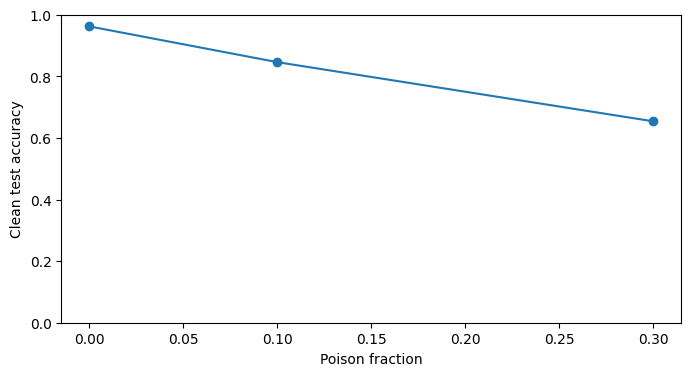

In [25]:
flip_probe = flip_labels(ytr, 0.1, 10)
if flip_probe is None:
    pending("A1")
else:
    yf, changed = flip_probe
    assert len(changed) == 60 and np.sum(yf != ytr) == 60
    assert np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(yf, ytr)
    flip_rows = []
    for rate in [0, 0.1, 0.3]:
        yf, changed = flip_labels(ytr, rate, 10)
        m = clean if rate == 0 else fit(Xtr, yf)[0]
        flip_rows.append({"poison_rate": rate, "n_changed": len(changed),
                         "clean_test_accuracy": acc(m, Xte, yte)})
    results["label_flipping"] = flip_rows
    display(pd.DataFrame(flip_rows))
    plt.plot([r["poison_rate"] for r in flip_rows],
             [r["clean_test_accuracy"] for r in flip_rows], "o-")
    plt.xlabel("Poison fraction"); plt.ylabel("Clean test accuracy")
    plt.ylim(0, 1); plt.show()

## B. Backdoor: локальный dirty-label опыт

Атакующий заменяет часть train на изображения с патчем 2×2 в правом нижнем углу и меткой `target=0`.
При инференсе тот же патч должен направлять нетаргетные цифры в класс 0.
Это учебная реализация идеи [BadNets](https://arxiv.org/abs/1708.06733), не точное воспроизведение статьи.
Доля отравления определяется от ВСЕХ 600 train, а выбираются только записи с исходной меткой, отличной от 0.

$
ASR=\frac{\sum_{i:y_i\ne t}1[\arg\max f(T(x_i))=t]}{|\{i:y_i\ne t\}|}.
$

Проверяем четыре условия: clean model / poisoned model × clean input / triggered input.
ASR clean-модели на том же триггере показывает, не объясняется ли эффект одним повреждением входа.
Дополнительно считаем условный ASR на тех нетаргетных объектах, которые эта же модель правильно распознавала без патча.

Знаменатель обязательно исключает объекты истинного целевого класса: иначе модель «случайно права» для них и метрика раздувается. Объект класса t не должен попадать ни в числитель, ни в знаменатель.

### Задание B1. Триггер и отравление

`trigger` должен копировать вход, сохранять форму `(n,64)` и менять только последние 2×2 пикселя.
`poison_data` заменяет, а не добавляет записи; возвращает индексы изменений.
Для воспроизводимого сравнения выбор индексов должен зависеть только от `seed`.

In [26]:
TARGET = 0

def trigger(x):
    """
    Наложить триггер: 2x2 патч из единиц в правом нижнем углу изображения 8x8.
    Возвращает НОВЫЙ массив той же формы (n, 64). Исходный x не меняется.
    """
    z = np.asarray(x).copy()           # копия — важно, исходные данные не трогаем
    z = z.reshape(-1, 8, 8)            # (n, 8, 8)
    z[:, -2:, -2:] = 1.0               # патч 2x2 в правом нижнем углу
    return z.reshape(-1, 64)           # обратно в (n, 64)


def poison_data(x, y, rate=0.15, target=TARGET, seed=42):
    """
    Заменить floor(rate * n) записей их триггерными версиями с меткой target.
    Меняются ТОЛЬКО записи, у которых исходная метка != target.

    Возвращает: xp (копия x с патчами), yp (копия y с target), ix (индексы испорченных).
    """
    x = np.asarray(x).copy()
    y = np.asarray(y).copy()
    n = len(y)
    n_poison = int(np.floor(rate * n))

    # Кандидаты — только объекты, чья метка изначально НЕ равна target.
    eligible = np.flatnonzero(y != target)

    # Детерминированный выбор индексов (только от seed).
    rng = np.random.default_rng(seed)
    ix = rng.choice(eligible, size=n_poison, replace=False)

    # Накладываем патч и подменяем метку. Заменяем, а не добавляем новые записи.
    x[ix] = trigger(x[ix])
    y[ix] = target

    return x, y, ix

### Задание B2. Корректный знаменатель 

Реализуйте ASR по уже вычисленным предсказаниям; возвращайте NaN, если допустимых объектов нет.
Не включайте истинный target-класс. Вызов не должен изменять массивы.

In [27]:
def targeted_asr(pred, y, target):
    """
    ASR на уже вычисленных предсказаниях.
    Знаменатель — только объекты с y != target.
    Если таких нет — возвращаем NaN (а не 0, чтобы не путать с «0 успехов»).
    """
    pred = np.asarray(pred)
    y = np.asarray(y)
    mask = y != target
    if mask.sum() == 0:
        return float("nan")
    return float((pred[mask] == target).mean())

,model,clean_accuracy,ASR,ASR_n,conditional_ASR,conditional_n,triggered_accuracy
0,clean,0.962,0.0,450,0.0,433,0.742
1,poisoned,0.956,1.0,450,1.0,429,0.100


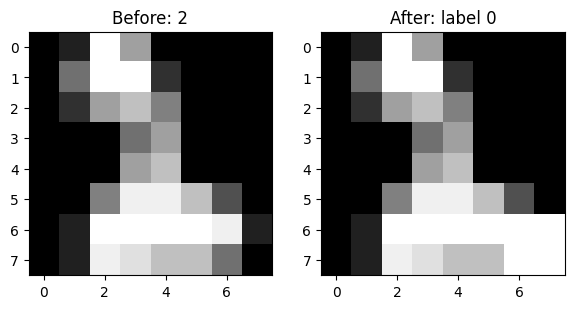

In [28]:
poisoned = None
probe = poison_data(Xtr, ytr)
asr_probe = targeted_asr(np.array([0, 0, 1]), np.array([0, 2, 3]), 0)
if probe is None or asr_probe is None or trigger(Xtr[:1]) is None:
    pending("B1/B2")
else:
    assert asr_probe == 0.5
    assert np.isnan(targeted_asr(np.array([0]), np.array([0]), 0))
    xp, yp, ix = probe
    assert len(ix) == 90 and np.all(yp[ix] == TARGET) and np.all(ytr[ix] != TARGET)
    keep = np.setdiff1d(np.arange(len(ytr)), ix)
    assert np.array_equal(xp[keep], Xtr[keep])
    assert np.array_equal(Xtr, X[train_ids]) and np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(xp, Xtr)
    assert np.all(trigger(Xtr[:2]).reshape(-1, 8, 8)[:, -2:, -2:] == 1)
    mask_pixels = np.ones((8, 8), bool); mask_pixels[-2:, -2:] = False
    assert np.array_equal(trigger(Xtr[:2]).reshape(-1,8,8)[:,mask_pixels],
                          Xtr[:2].reshape(-1,8,8)[:,mask_pixels])
    poisoned, _ = fit(xp, yp)
    bd_rows = []
    for name, model in [("clean", clean), ("poisoned", poisoned)]:
        pc = probs(model, Xte).argmax(1)
        pt = probs(model, trigger(Xte)).argmax(1)
        eligible = (yte != TARGET) & (pc == yte)
        bd_rows.append({"model": name, "clean_accuracy": accuracy_score(yte, pc),
                        "ASR": targeted_asr(pt, yte, TARGET),
                        "ASR_n": int((yte != TARGET).sum()),
                        "conditional_ASR": float((pt[eligible] == TARGET).mean()),
                        "conditional_n": int(eligible.sum()),
                        "triggered_accuracy": accuracy_score(yte, pt)})
    results["backdoor"] = bd_rows
    display(pd.DataFrame(bd_rows))
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(Xtr[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"Before: {ytr[ix[0]]}")
    ax[1].imshow(xp[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title(f"After: label {yp[ix[0]]}")
    plt.tight_layout(); plt.show()

### Контроль защиты с известным триггером

Ниже защитник УЖЕ знает положение патча. Он зануляет эту область на ВСЕХ входах.
Это oracle-sanitization: полезный контроль причинности, но не детектор неизвестных backdoor.
Считаем и ASR, и потерю clean accuracy. Дополнительный опыт: fine-tuning на чистой validation;
после него эта выборка становится обучающей и больше не годится для независимой оценки.
Ни один из этих опытов не даёт универсальной гарантии ([NIST](https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.100-2e2025.pdf)).

,defense,clean_accuracy,ASR
0,No defense,0.956,1.000000
1,Known patch erase,0.956,0.002222
2,Clean fine-tuning,0.960,0.997778


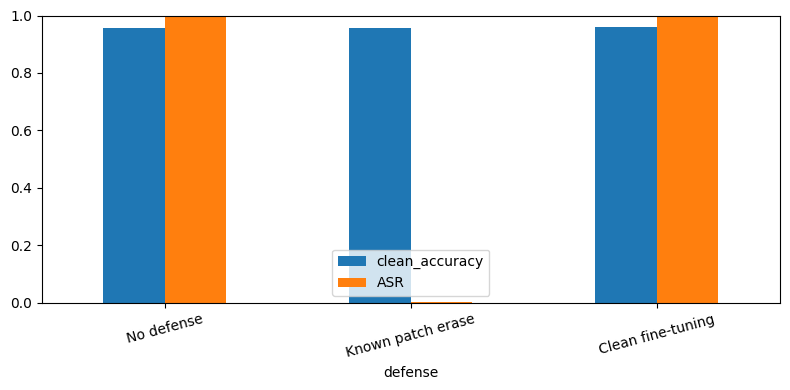

In [29]:
def erase_known_patch(x):
    z = x.copy().reshape(-1,8,8)
    z[:, -2:, -2:] = 0
    return z.reshape(-1,64)

if poisoned is not None:
    ft = copy.deepcopy(poisoned)
    opt = torch.optim.Adam(ft.parameters(), lr=0.001)
    for _ in range(40):
        opt.zero_grad()
        loss = F.cross_entropy(ft(tensor(Xval)), torch.as_tensor(yval, dtype=torch.long))
        loss.backward(); opt.step()
    defense_rows = []
    for name, model, transform in [
        ("No defense", poisoned, lambda x: x),
        ("Known patch erase", poisoned, erase_known_patch),
        ("Clean fine-tuning", ft.eval(), lambda x: x)]:
        defense_rows.append({"defense": name, "clean_accuracy": acc(model, transform(Xte), yte),
                            "ASR": targeted_asr(probs(model, transform(trigger(Xte))).argmax(1), yte, TARGET)})
    results["backdoor_defense"] = defense_rows
    display(pd.DataFrame(defense_rows))
    pd.DataFrame(defense_rows).set_index("defense").plot.bar(rot=15, ylim=(0,1))
    plt.tight_layout(); plt.show()
else:
    pending("Backdoor defense")

,rate,seed,n_poisoned,clean_accuracy,ASR
0,0.05,42,30,0.960,0.997778
1,0.15,42,90,0.956,1.000000
2,0.25,42,150,0.960,1.000000
3,0.05,43,30,0.962,0.953333
4,0.15,43,90,0.956,0.980000
5,0.25,43,150,0.958,1.000000
6,0.05,44,30,0.966,0.977778
7,0.15,44,90,0.972,0.995556
8,0.25,44,150,0.968,1.000000


,rate,n_seeds,clean_mean,clean_sd,asr_mean,asr_sd
0,0.05,3,0.962667,0.003055,0.976296,0.022259
1,0.15,3,0.961333,0.009238,0.991852,0.010502
2,0.25,3,0.962000,0.005292,1.000000,0.000000


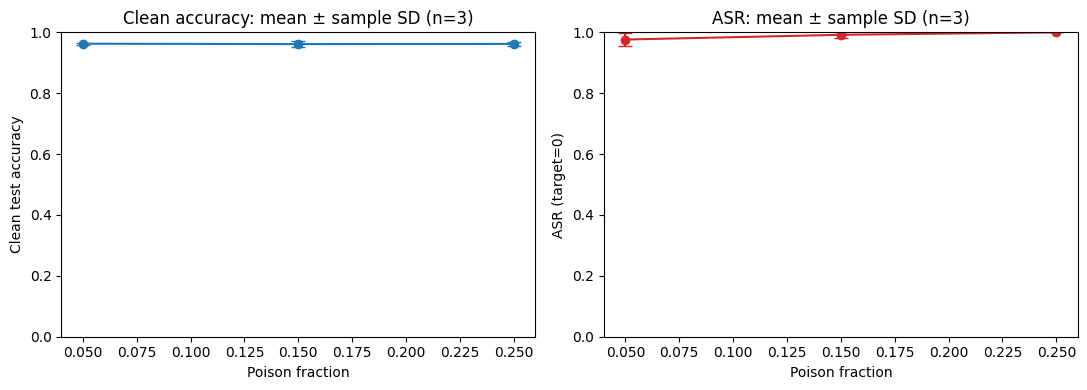

In [30]:
# ===== F1: Backdoor — доли 0.05 / 0.15 / 0.25 на трёх seed =====
# Патч и target не меняем: trigger() и TARGET=0 те же, что в блоке B.

bd_seeds = [42, 43, 44]
bd_rates = [0.05, 0.15, 0.25]

bd_raw = []  # сырые строки: (rate, seed, n_poisoned, clean_acc, ASR)
for seed in bd_seeds:
    for rate in bd_rates:
        # 1) Готовим отравленный train этим seed'ом.
        #    Один и тот же seed определяет и выбор индексов, и инициализацию модели —
        #    весь прогон полностью детерминирован.
        xp, yp, ix = poison_data(Xtr, ytr, rate=rate, target=TARGET, seed=seed)

        # 2) Обучаем модель-кандидата на отравленном наборе.
        m, _ = fit(xp, yp, seed=seed)

        # 3) Метрики на чистом test: чистая точность и ASR по триггеру.
        pc = probs(m, Xte).argmax(1)
        pt = probs(m, trigger(Xte)).argmax(1)
        clean_acc = accuracy_score(yte, pc)
        asr = targeted_asr(pt, yte, TARGET)

        bd_raw.append({
            "rate": rate, "seed": seed, "n_poisoned": len(ix),
            "clean_accuracy": clean_acc, "ASR": asr,
        })

bd_df = pd.DataFrame(bd_raw)
display(bd_df)

# 4) Агрегация: mean и sample SD (ddof=1) по трём seed для каждой доли.
def _sd(s):
    return float(np.std(s, ddof=1))   # sample SD, не population SD

bd_summary = (bd_df.groupby("rate")
              .agg(n_seeds       = ("seed", "count"),
                   clean_mean    = ("clean_accuracy", "mean"),
                   clean_sd      = ("clean_accuracy", _sd),
                   asr_mean      = ("ASR", "mean"),
                   asr_sd        = ("ASR", _sd))
              .reset_index())
display(bd_summary)

# 5) График: точки — средние по трём seed, усы — ±sample SD (НЕ доверительный интервал).
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].errorbar(bd_summary["rate"], bd_summary["clean_mean"],
               yerr=bd_summary["clean_sd"], fmt="o-", capsize=5, color="C0")
ax[0].set(xlabel="Poison fraction", ylabel="Clean test accuracy", ylim=(0, 1))
ax[0].set_title("Clean accuracy: mean ± sample SD (n=3)")

ax[1].errorbar(bd_summary["rate"], bd_summary["asr_mean"],
               yerr=bd_summary["asr_sd"], fmt="o-", capsize=5, color="C3")
ax[1].set(xlabel="Poison fraction", ylabel="ASR (target=0)", ylim=(0, 1))
ax[1].set_title("ASR: mean ± sample SD (n=3)")

plt.tight_layout(); plt.show()

results["backdoor_f1"] = {
    "raw": bd_raw,
    "summary": bd_summary.to_dict("records"),
}

Гипотеза о насыщении подтвердилась и даже раньше, чем ожидалось. Уже при 5% (30 отравленных объектов из 600) средний ASR равен 0.976. То есть атакующему достаточно заменить всего 30 картинок — и триггер срабатывает почти всегда. При 25% ASR доходит до 1.000 на всех трёх seed. Порог насыщения находится где-то между 5% и 15%: при 0.15 уже 0.992 с разбросом 0.011, что практически неотличимо от 1.0.

Гипотеза о невидимости подтвердилась. Чистая точность не падает ни на йоту. Средние 0.9627 / 0.9613 / 0.9620 — это одно и то же число. Модель, заражённая на 25% train-объектов, показывает на чистом тесте ту же точность, что и модель, заражённая на 5%. Clean accuracy не является сигналом о наличии backdoor — и это видно на числах прямо, а не как рассуждение.

Гипотеза о разбросе подтвердилась. Sample SD по ASR монотонно убывает с ростом доли: 0.022 → 0.011 → 0.000. При 5% на seed 43 ASR = 0.9533, на seed 42 — 0.9978: разница почти 4.5 процентных пункта. При 25% все три seed дают ровно 1.0. Это значит, что атакующему с бюджетом 5% приходится «надеяться» на удачу: конкретный случайный набор 30 объектов может дать ASR от 0.95 до 0.998. С бюджетом 25% такой неопределённости уже нет.

## C. Membership inference: отдельный синтетический стенд

Определяем, входила ли запись `(x,y)` в train целевой модели.
Loss-score требует истинной метки и вектора вероятностей: это явно заданные возможности атакующего.
Используем отрицательную cross-entropy, то есть `log p(y|x)`; больший score означает «вероятнее member».
Идея shadow calibration связана с [Shokri et al.](https://arxiv.org/abs/1610.05820).

1600 синтетических записей делятся на 4 непересекающихся набора по 400:
target members, target nonmembers, shadow members, shadow nonmembers.
Shadow-данные и алгоритм обучения доступны атакующему. Порог выбирается ТОЛЬКО на shadow;
истинные membership-метки target открываются лишь оценщику после атаки.
Один shadow не является реализацией LiRA. Цель: честно показать принцип калибровки.

Похоже, проблема в том, что я обернул всё в ` ```markdown ` — из-за этого формулы не рендерятся, а показываются как код.  
Вот тот же текст **без внешнего code fence**, готовый для вставки в Markdown с поддержкой MathJax/KaTeX:

---

### Блок C. Membership Inference Attack (MIA)

**Теория**

MIA — атака, призванная определить, входила ли конкретная запись $(x, y)$ в обучающий набор целевой модели.  
Идея: модель на членах обучающей выборки обычно даёт более высокий $\log p(y \mid x)$ — то есть меньший loss — чем на не-членах. Порог отделяет «мемберов» от «не-мемберов».

Чтобы выбрать порог без утечки, используется shadow-модель: она обучается на своих shadow-данных, для которых известны метки membership. Порог подбирается по balanced accuracy на shadow и переносится на целевую модель. Это упрощённая версия идеи Shokri et al., не LiRA.

**Loss-score:**

$$
s(x, y) = \log p_\theta(y \mid x)
$$

Больший $s(x, y)$ → «вероятнее мембер».

**Порог:**

$$
\tau^* = \arg\max_{\tau} \mathrm{BalancedAccuracy}_{\text{shadow}}(\tau)
$$

Затем порог переносится на целевую модель:

$$
\hat{m}(x, y) =
\begin{cases}
1, & s(x, y) \ge \tau^*, \\
0, & s(x, y) < \tau^*.
\end{cases}
$$

**Формула PPV (positive predictive value) при доле мемберов $\pi$:**

$$
\mathrm{PPV}
=
\frac{\mathrm{TPR}\,\pi}
{\mathrm{TPR}\,\pi + \mathrm{FPR}\,(1-\pi)}
$$

При малом $\pi$ даже неплохие $\mathrm{TPR}$ и $\mathrm{FPR}$ дают низкий $\mathrm{PPV}$ — это критично для реалистичных сценариев.

Нужен способ выбрать порог без знания ответов на целевые данные. Именно для этого нужен shadow.  
Shadow-модель — это модель, обученная на другом наборе данных, но тем же самым алгоритмом и с той же архитектурой, что и целевая модель. Shadow-набор — это данные, которые атакующий контролирует: он сам их собрал, сам обучил на них shadow-модель, и точно знает, какие объекты были в её train, а какие нет.  

Shadow-данные и целевые данные не пересекаются, но распределение у них одинаковое (сгенерированы одним make_classification), поэтому shadow-модель ведёт себя «похоже» на целевую.  

1. Обучаем shadow-модель на её 400 мемберах (sm).
2. Считаем score на shadow-данных: и на её мемберах (sm), и на её не-мемберах (sn). Для них мы знаем истинный ответ — shadow-мемберы точно были в train shadow-модели, shadow-не-мемберы точно не были.
3. Подбираем порог τ на этих shadow-score'ах так, чтобы он хорошо разделял мемберов и не-мемберов shadow.
4. Переносим τ на целевую модель. Считаем score целевой модели на целевых данных (tm, tn) и применяем к ним тот же порог, ничего не зная про их истинные метки membership.

Shadow-модель ведёт себя похоже на целевую, потому что обучается тем же алгоритмом на данных того же распределения. Значит, порог, который сработал на shadow, разумно ожидать сработает и на target.

### Задание C1. Loss-score и порог 

Напишите `membership_score` через логарифм вероятности истинного класса с защитой от log(0).
В `choose_threshold` максимизируйте balanced accuracy на calibration, перебрав уникальные score
и дополнительный порог выше максимума. Используйте соглашение `score >= threshold`.

In [31]:
def membership_score(p, labels):
    """
    Loss-score: log вероятности истинного класса для каждой записи.
    p — матрица (n, k) вероятностей (softmax на выходе модели).
    labels — (n,) истинные метки.

    Защита от log(0): clip снизу малым эпсилоном.
    """
    p = np.asarray(p)
    labels = np.asarray(labels)
    idx = np.arange(len(labels))
    true_p = p[idx, labels]                       # вероятность именно истинного класса
    true_p = np.clip(true_p, 1e-12, 1.0)          # защита от log(0)
    return np.log(true_p)


def choose_threshold(scores, member):
    """
    Подбор порога ТОЛЬКО по calibration-данным (обычно shadow).
    Критерий — balanced accuracy (устойчив к дисбалансу классов).
    Соглашение: score >= threshold → предсказан «member».
    """
    scores = np.asarray(scores)
    member = np.asarray(member)

    # Кандидаты: все уникальные score + один «выше максимума» (чтобы можно было никого не считать мембером).
    candidates = np.unique(scores)
    candidates = np.r_[candidates, candidates.max() + 1e-9]

    best_thr, best_ba = float(candidates[0]), -1.0
    for thr in candidates:
        pred = scores >= thr
        ba = balanced_accuracy_score(member, pred)
        if ba > best_ba:
            best_ba = ba
            best_thr = float(thr)
    return best_thr

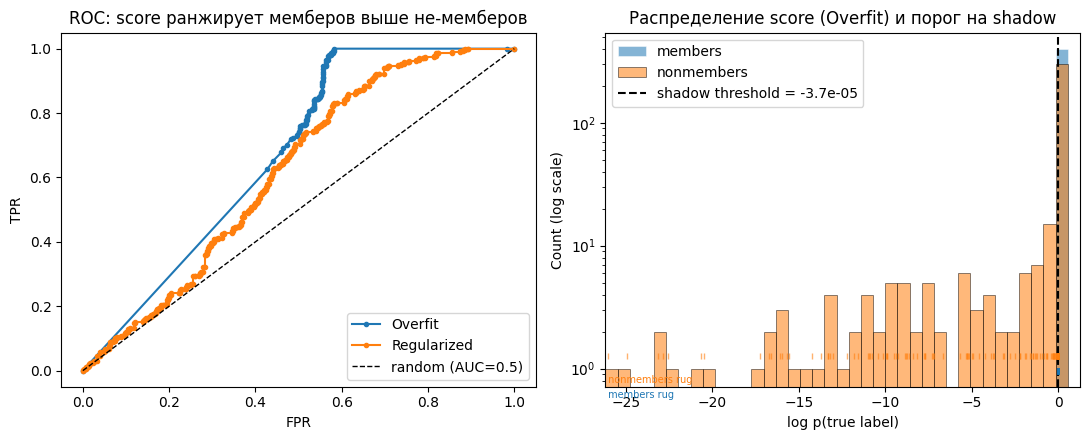

,setting,train_accuracy,nonmember_accuracy,gap,threshold_shadow,ROC_AUC,balanced_accuracy,TPR,FPR,advantage,TPR_at_empirical_FPR_le_1pct
0,Overfit,1.0000,0.7825,0.2175,-0.000037,0.671647,0.7075,1.00,0.585,0.415,0.00
1,Regularized,0.9825,0.8175,0.1650,-0.337439,0.618344,0.6200,0.94,0.700,0.240,0.01


Минимальный ненулевой шаг FPR = 0.0025 ; 1% соответствует всего 4 FP, оценка нестабильна.


In [32]:
mia_probe = membership_score(np.array([[.9,.1],[.2,.8]]), np.array([0,1]))
if mia_probe is None or choose_threshold(np.array([-2., -1.]), np.array([0,1])) is None:
    pending("C1")
else:
    np.testing.assert_allclose(mia_probe, np.log([.9,.8]))
    threshold_probe = choose_threshold(np.array([-3.,-2.,-1.,-.1]), np.array([0,0,1,1]))
    assert balanced_accuracy_score([0,0,1,1], np.array([-3.,-2.,-1.,-.1]) >= threshold_probe) == 1

    XM, yM = make_classification(n_samples=1600, n_features=40, n_informative=12,
                                 n_redundant=8, class_sep=0.7, flip_y=0.08, random_state=51)
    mi = np.arange(1600)
    a, b = train_test_split(mi, test_size=800, random_state=52, stratify=yM)
    tm, tn = train_test_split(a, test_size=400, random_state=53, stratify=yM[a])
    sm, sn = train_test_split(b, test_size=400, random_state=54, stratify=yM[b])
    assert len(set(np.r_[tm, tn, sm, sn])) == 1600

    # Фиксированное масштабирование, а не fit scaler по test.
    XM = (XM / 5.0).astype(np.float32)
    member = np.r_[np.ones(400, int), np.zeros(400, int)]
    evaluation_ids, calibration_ids = np.r_[tm, tn], np.r_[sm, sn]

    mia_rows = []
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    for name, epochs, wd in [("Overfit", 400, 0.0), ("Regularized", 60, 0.02)]:
        victim, _ = fit(XM[tm], yM[tm], k=2, epochs=epochs, wd=wd, width=96, seed=61)
        shadow, _ = fit(XM[sm], yM[sm], k=2, epochs=epochs, wd=wd, width=96, seed=62)

        # Порог подбирается ТОЛЬКО на shadow, потом применяется к target.
        cal_s = membership_score(probs(shadow, XM[calibration_ids]), yM[calibration_ids])
        threshold = choose_threshold(cal_s, member)

        # Score на target-записях: первые 400 — мемберы, последние 400 — не-мемберы.
        s = membership_score(probs(victim, XM[evaluation_ids]), yM[evaluation_ids])
        guessed = s >= threshold
        tpr = float(guessed[:400].mean())
        fpr = float(guessed[400:].mean())

        roc_fpr, roc_tpr, _ = roc_curve(member, s)
        low = float(roc_tpr[roc_fpr <= .01].max())

        train_acc = acc(victim, XM[tm], yM[tm])
        test_acc = acc(victim, XM[tn], yM[tn])

        mia_rows.append({
            "setting": name,
            "train_accuracy": train_acc,
            "nonmember_accuracy": test_acc,
            "gap": train_acc - test_acc,
            "threshold_shadow": threshold,
            "ROC_AUC": roc_auc_score(member, s),
            "balanced_accuracy": balanced_accuracy_score(member, guessed),
            "TPR": tpr, "FPR": fpr, "advantage": tpr - fpr,
            "TPR_at_empirical_FPR_le_1pct": low,
        })

        # ---------- Левый график: ROC ----------
        axes[0].plot(roc_fpr, roc_tpr, marker="o", markersize=3, label=name)

        # ---------- Правый график: гистограмма score для Overfit ----------
        if name == "Overfit":
            # Явный x-диапазон по 1-му и 99-му перцентилю, чтобы редкие
            # выбросы с очень отрицательным score не сжимали всю картинку.
            lo = float(np.percentile(s, 1.0))
            hi = float(np.percentile(s, 99.0))
            pad = 0.05 * (hi - lo) if hi > lo else 0.1
            xlim = (lo - pad, hi + pad)

            # Общие бины для обеих гистограмм — иначе бары не совпадают по x.
            bins = np.linspace(xlim[0], xlim[1], 40)

            # Две гистограммы с прозрачностью и обводкой, чтобы пересечение
            # было видно и бары не сливались в одно пятно.
            axes[1].hist(s[:400], bins=bins, alpha=0.55,
                         color="tab:blue", edgecolor="white", linewidth=0.6,
                         label="members")
            axes[1].hist(s[400:], bins=bins, alpha=0.55,
                         color="tab:orange", edgecolor="black", linewidth=0.6,
                         label="nonmembers")

            # Порог: если внутри xlim — рисуем как есть; если снаружи —
            # всё равно показываем, прижав к краю и подписав в легенде.
            if xlim[0] <= threshold <= xlim[1]:
                axes[1].axvline(threshold, color="black", linestyle="--",
                                linewidth=1.5,
                                label=f"shadow threshold = {threshold:.3g}")
            else:
                side = "правее" if threshold > xlim[1] else "левее"
                edge = xlim[1] if threshold > xlim[1] else xlim[0]
                axes[1].axvline(edge, color="black", linestyle="--",
                                linewidth=1.5,
                                label=f"shadow threshold = {threshold:.3g} ({side} графика)")

            axes[1].set_xlim(*xlim)

            # Log-шкала по y: пик мемберов может быть высотой ~400,
            # без лога оранжевые бары становятся плоскими.
            axes[1].set_yscale("log")

            # Rug-plot: полоски на дне показывают, где лежат отдельные точки.
            ymin, ymax = axes[1].get_ylim()
            rug_y_members = ymin * 1.3
            rug_y_nonmembers = ymin * 1.7
            axes[1].plot(s[:400], np.full(400, rug_y_members), "|",
                         color="tab:blue", markersize=5, alpha=0.6)
            axes[1].plot(s[400:], np.full(400, rug_y_nonmembers), "|",
                         color="tab:orange", markersize=5, alpha=0.6)
            axes[1].text(xlim[0], rug_y_nonmembers * 0.7, " nonmembers rug",
                         fontsize=7, color="tab:orange", ha="left", va="top")
            axes[1].text(xlim[0], rug_y_members * 0.7, " members rug",
                         fontsize=7, color="tab:blue", ha="left", va="top")

    # Диагональ для сравнения: случайный угадыватель (AUC = 0.5).
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="random (AUC=0.5)")
    axes[0].set(xlabel="FPR", ylabel="TPR",
                title="ROC: score ранжирует мемберов выше не-мемберов")
    axes[0].legend(loc="lower right")

    axes[1].set(xlabel="log p(true label)", ylabel="Count (log scale)",
                title="Распределение score (Overfit) и порог на shadow")
    axes[1].legend(loc="upper left")

    plt.tight_layout()
    plt.show()

    results["membership"] = mia_rows
    display(pd.DataFrame(mia_rows))
    print("Минимальный ненулевой шаг FPR =", 1 / 400,
          "; 1% соответствует всего 4 FP, оценка нестабильна.")

Модель обычно увереннее на тех объектах, которые она видела при обучении. Если модель переобучена, она почти «запомнила» тренировочные примеры, и вероятность истинного класса на них близка к 1. А на новых примерах она менее уверена.  

Значит, можно придумать числовую характеристику — score — которая для мемберов в среднем выше, чем для не-мемберов.  

То есть для каждой записи мы берём вероятность именно истинного класса (не argmax!), и логарифмируем её. Чем больше уверенность, тем выше score.  

**Пример. Модель выдала вероятности [0.9, 0.1] для метки 0. Score = log(0.9) ≈ -0.105. Для метки 1 и вероятностей [0.2, 0.8] score = log(0.8) ≈ -0.223**  

Чем score больше (то есть ближе к нулю, менее отрицательный) — тем увереннее модель, тем вероятнее, что запись была мембером.  

Мы знаем: у мемберов score в среднем выше, у не-мемберов — ниже. Но score — это непрерывное число. Нужно превратить его в бинарное решение «мембер / не-мембер». Для этого нужен порог τ:

- если score ≥ τ → говорим «мембер»;
- если score < τ → говорим «не-мембер».

Вопрос: как выбрать τ? Это и есть проблема. От порога зависят все ошибки.  

TPR (True Positive Rate, ещё называют чувствительностью): TP / (TP + FN). Это доля мемберов, которых атака поймала. Чем выше — тем лучше атака.  
FPR (False Positive Rate): FP / (FP + TN). Это доля не-мемберов, которых атака ошибочно назвала мемберами. Чем ниже — тем лучше.  

я: у каждой атаки есть не одна пара (TPR, FPR), а целая кривая — по одному значению для каждого возможного порога. Эта кривая и называется ROC-кривая.  

Идея простая: перебираем все возможные пороги и для каждого рисуем точку (FPR, TPR).  

AUC (Area Under Curve) — площадь под этой кривой. Она от 0 до 1.

- AUC = 0.5 → кривая лежит на диагонали → атака не различает мемберов и не-мемберов.
- AUC = 1.0 → кривая в идеальном углу → атака различает идеально.
- AUC = 0.7 → атака достаточно сильная.

Интерпретация AUC: вероятность, что случайно взятый мембер получит score выше, чем случайно взятый не-мембер. 


### Интерпретация C

ROC-AUC оценивает ранжирование, а balanced accuracy, TPR и FPR выше относятся к порогу,
заранее выбранному на shadow. `TPR_at_empirical_FPR_le_1pct` является описательной точкой
ROC по итоговому test, НЕ рабочим порогом, который разрешено подобрать по test.
Не выдавайте эту оценку за гарантию при FPR 0.1%: 400 nonmembers недостаточно для надёжного анализа хвоста.
Важность low-FPR оценки обсуждается в [Carlini et al.](https://arxiv.org/abs/2112.03570).

При доле участников $\pi$ среди проверяемых записей:
$
PPV=\frac{TPR\pi}{TPR\pi+FPR(1-\pi)}.
$

При TPR=0.6, FPR=0.1 и $\pi=0.01$ точность положительного заключения составляет около 5.7%.
Сбалансированный стенд сам по себе этого не показывает.
Снижение риска при регуляризации является эмпирическим результатом, не differential privacy.

In [33]:
pi, tpr_example, fpr_example = .01, .6, .1
ppv = tpr_example*pi / (tpr_example*pi + fpr_example*(1-pi))
assert np.isclose(ppv, .05714285714285714)
print(f"Пример PPV = {ppv:.2%}")

Пример PPV = 5.71%


**PPV** (positive predictive value) показывает, насколько «страшна» атака в реальном сценарии с редкими мемберами:

$$
\mathrm{PPV} = \frac{\mathrm{TPR} \cdot \pi}{\mathrm{TPR} \cdot \pi + \mathrm{FPR} \cdot (1 - \pi)}
$$

При TPR = 0.6, FPR = 0.1 и доле мемберов π = 0.01 получается всего ~5.7% — то есть из 100 «положительных» срабатываний атаки только ~5.7 реально указывают на мембера. Сбалансированный стенд сам по себе этого не показывает: там π = 0.5, и PPV будет гораздо выше.

## D. Model inversion: оптимизация входа

Доступ white-box: атакующий знает веса и получает градиент по входу, но НЕ использует train в оптимизации.
Синтезируем изображение класса $c$, минимизируя
$
L(x)=-\log p_\theta(c\mid x)+0.02\|x\|_2^2/d+0.05\,TV(x),\quad x\in[0,1]^{64}.
$

Здесь TV равна сумме средних абсолютных разностей по двум направлениям.
Это демонстрация class-prototype inversion. Она НЕ доказывает извлечение конкретной обучающей записи;
близость к train оценивается отдельно только преподавателем-аудитором.
Связь confidence и inversion изучается в [Fredrikson et al.](https://www.cs.cmu.edu/~mfredrik/papers/fjr2015ccs.pdf).

### Задание D1. Функция потерь и градиент по входу 
Верните скалярную функцию потерь для батча восстанавливаемых изображений.
Нельзя использовать `.detach()` или NumPy внутри loss: градиент должен доходить до `x`.
Оптимизатор ниже меняет только `x`, веса модели фиксированы.

In [34]:
def inversion_loss(model, x, classes):
    """
    Функция потерь для батча восстанавливаемых изображений.
    ВАЖНО: нельзя использовать .detach() или numpy — иначе градиент не дойдёт до x.

    x       : torch.Tensor (B, 64), requires_grad=True
    classes : torch.Tensor (B,), истинные целевые классы для инверсии
    """
    # 1) CE: -log p(c|x)
    logits = model(x)
    ce = F.cross_entropy(logits, classes)

    # 2) L2-регуляризация: 0.02 * ||x||^2 / d = 0.02 * mean(x^2) по всем элементам.
    l2 = 0.02 * (x ** 2).mean()

    # 3) Total variation: сумма средних |Δ| по двум пространственным осям.
    z = x.reshape(-1, 8, 8)
    tv_h = (z[:, 1:, :] - z[:, :-1, :]).abs().mean()   # разности по строкам
    tv_w = (z[:, :, 1:] - z[:, :, :-1]).abs().mean()   # разности по столбцам
    tv = 0.05 * (tv_h + tv_w)

    return ce + l2 + tv

,class,restart,confidence,nearest_train_MSE,nearest_test_MSE,nref_each
0,0,0,0.999849,0.114259,0.116033,50
1,0,1,1.000000,0.149207,0.152763,50
2,3,0,1.000000,0.152829,0.146404,51
3,3,1,0.999999,0.145224,0.133860,51
4,8,0,0.999904,0.163195,0.162981,48
5,8,1,0.999855,0.157693,0.167334,48


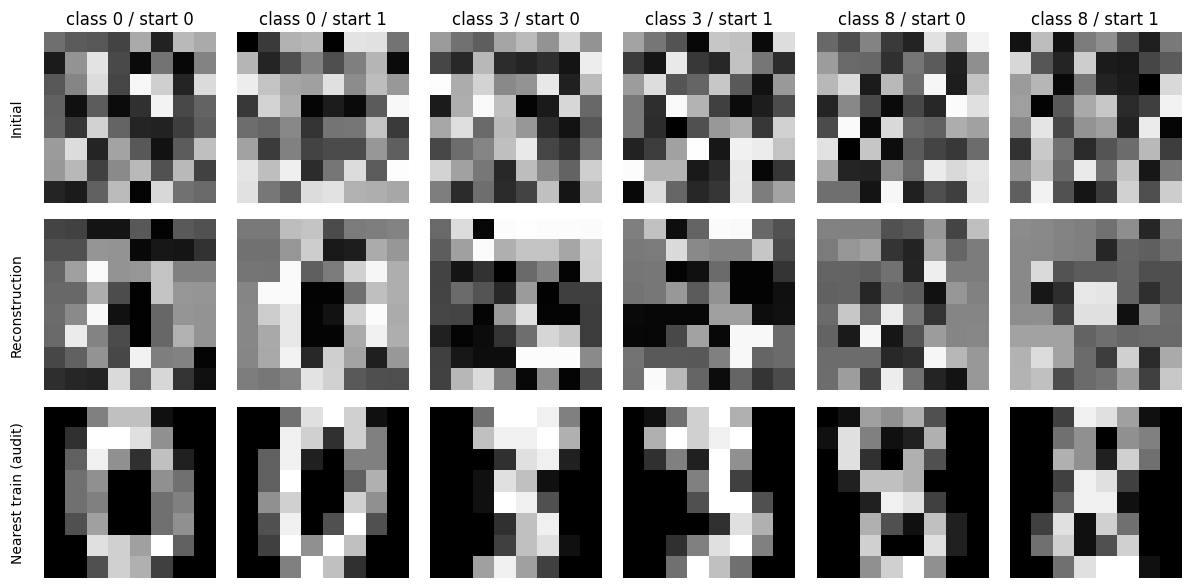

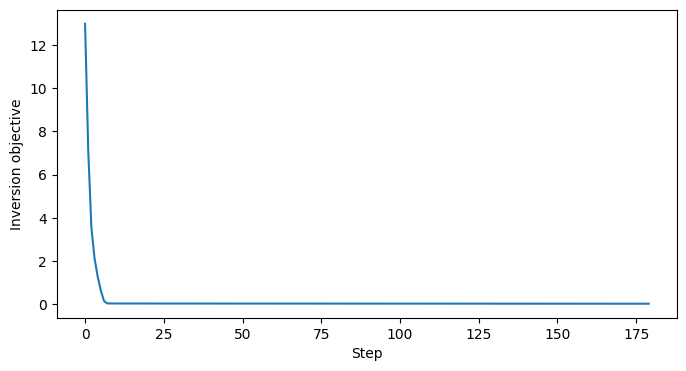

In [35]:
inverse_probe_x = torch.full((2,64), .5, requires_grad=True)
inverse_probe = inversion_loss(clean, inverse_probe_x, torch.tensor([0,1]))
if inverse_probe is None:
    pending("D1")
else:
    assert inverse_probe.ndim == 0
    grad = torch.autograd.grad(inverse_probe, inverse_probe_x)[0]
    assert torch.isfinite(grad).all() and grad.abs().sum() > 0
    before_weights = [p.detach().clone() for p in clean.parameters()]
    for p in clean.parameters():
        p.requires_grad_(False)
    # Два старта для каждого из трёх классов.
    classes = torch.tensor([0,0,3,3,8,8], dtype=torch.long)
    torch.manual_seed(70)
    inv_x = torch.rand((6,64), requires_grad=True)
    initial = inv_x.detach().numpy().copy()
    opt_x = torch.optim.Adam([inv_x], lr=.04)
    inv_hist = []
    for _ in range(180):
        opt_x.zero_grad()
        loss = inversion_loss(clean, inv_x, classes)
        loss.backward(); opt_x.step()
        with torch.no_grad():
            inv_x.clamp_(0,1)
        inv_hist.append(loss.item())
    recon = inv_x.detach().numpy()
    assert all(torch.equal(p, old) for p,old in zip(clean.parameters(), before_weights))
    for p in clean.parameters():
        p.requires_grad_(True)
    # Аудиторский доступ: ближайшие train и held-out не входят в атакующую оптимизацию.
    rows, nearest_train = [], []
    for i, cls in enumerate(classes.numpy()):
        tri = np.flatnonzero(ytr == cls); tei = np.flatnonzero(yte == cls)
        # Одинаковое число кандидатов, чтобы размер множества не смещал nearest-neighbor baseline.
        nref = min(len(tri), len(tei)); tri, tei = tri[:nref], tei[:nref]
        dtr = ((Xtr[tri]-recon[i])**2).mean(1)
        dte = ((Xte[tei]-recon[i])**2).mean(1)
        nearest_train.append(Xtr[tri[dtr.argmin()]])
        rows.append({"class": int(cls), "restart": i%2,
                     "confidence": float(probs(clean,recon[i:i+1])[0,cls]),
                     "nearest_train_MSE": float(dtr.min()),
                     "nearest_test_MSE": float(dte.min()), "nref_each": nref})
    results["inversion"] = rows
    display(pd.DataFrame(rows))
    fig, ax = plt.subplots(3,6, figsize=(12,6))
    for i in range(6):
        for r, arr in enumerate([initial, recon, np.array(nearest_train)]):
            ax[r,i].imshow(arr[i].reshape(8,8), cmap="gray", vmin=0, vmax=1)
            ax[r,i].axis("off")
        ax[0,i].set_title(f"class {classes[i].item()} / start {i%2}")
    for r,label in enumerate(["Initial", "Reconstruction", "Nearest train (audit)"]):
        ax[r,0].text(-.2,.5,label, transform=ax[r,0].transAxes, rotation=90, va="center")
    plt.tight_layout(); plt.show()
    plt.plot(inv_hist); plt.xlabel("Step"); plt.ylabel("Inversion objective"); plt.show()

## E. Model extraction: локальный API с бюджетом

Цель: скопировать предсказания, а не восстановить точные веса.
Атакующий видит только свои query-входы и ответ API; метки `ytr`, `yte`, `y[pool_ids]` не используются в fit клона.
Ниже сравниваются soft probabilities и hard labels при равных бюджетах уникальных примеров.
Идея prediction-API extraction: [Tramèr et al.](https://arxiv.org/abs/1609.02943).
API является программной границей эксперимента, не защищённым процессом: владелец блокнота технически видит все переменные.

Чтобы не платить за одни и те же запросы повторно, один раз получаем 500 ответов и кэшируем их.
Модели с бюджетом 50/150/500 получают только соответствующий префикс ответов.
В эксплуатации метрики аудита потребовали бы отдельного доступа оценщика;
здесь он считает fidelity на test напрямую и не расходует бюджет атакующего.

### Model Extraction

**Идея.** Model extraction — попытка скопировать поведение чёрного ящика (API) через запросы. Атакующий имеет доступ к публичному пулу $X_{\text{pool}}$ (но без меток) и к API, отдающему вероятности. Цель — обучить модель-клон, воспроизводящую выходы жертвы.

**Fidelity** — совпадение предсказаний клона и жертвы на одном и том же входе:

$$
\mathrm{fidelity}
=
\Pr_{x}\!\left[\arg\max f_{\text{clone}}(x) = \arg\max f_{\text{victim}}(x)\right]
$$

**Accuracy** — совпадение с истинными метками $y$. Клон может иметь высокую fidelity и низкую accuracy: он скопировал не истину, а именно решения жертвы, включая её ошибки.

**Soft-label дистилляция** использует полное распределение teacher (softmax-вероятности). **Hard-label** — только $\arg\max$. Soft обычно даёт более высокую fidelity при том же бюджете запросов.

### Задание E1. Дистилляция

Реализуйте soft cross-entropy по logits student и распределению teacher.
Не передавайте вероятности как logits в `cross_entropy`.
Для hard-label варианта используется стандартная cross-entropy с argmax teacher.

In [36]:
def distill_loss(logits, teacher_p):
    """
    Soft cross-entropy между логитами student и распределением teacher.
    НЕЛЬЗЯ передавать teacher_p как logits в F.cross_entropy (это вероятности, не логиты!).

    logits    : (B, k) — выход student
    teacher_p : (B, k) — вероятности teacher, сумма по классу = 1
    """
    log_prob = F.log_softmax(logits, dim=1)           # log softmax student
    return -(teacher_p * log_prob).sum(dim=1).mean()  # кросс-энтропия с мягкими метками

,queries_available,output,fidelity,clone_accuracy,victim_accuracy
0,50,soft,0.772,0.760,0.962
1,50,hard,0.734,0.730,0.962
2,150,soft,0.930,0.912,0.962
3,150,hard,0.894,0.880,0.962
4,500,soft,0.960,0.950,0.962
5,500,hard,0.950,0.938,0.962


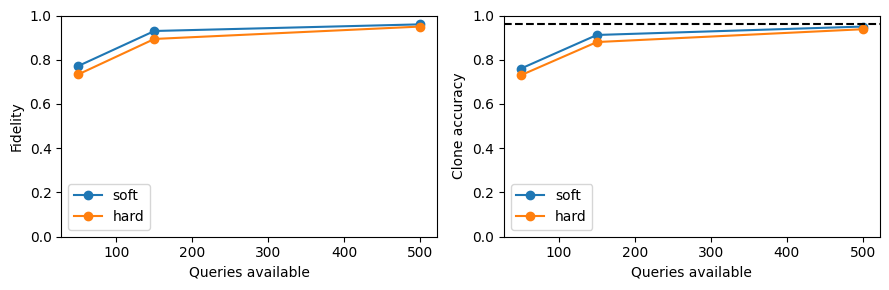

Всего запросов к API в этом опыте: 500


In [37]:
class LocalAPI:
    def __init__(self, model, budget=500):
        self.__model = model
        self.budget, self.used = budget, 0
    def query(self, x):
        if self.used + len(x) > self.budget:
            raise RuntimeError("Query budget exceeded")
        self.used += len(x)
        return probs(self.__model, x)

dl_probe = distill_loss(torch.zeros(2,10, requires_grad=True), torch.full((2,10), .1))
if dl_probe is None:
    pending("E1")
else:
    assert torch.isclose(dl_probe.detach(), torch.tensor(np.log(10), dtype=torch.float32))
    api = LocalAPI(clean, budget=500)
    order = np.random.default_rng(80).permutation(len(Xpool))
    queries = Xpool[order]
    cached_answers = api.query(queries)
    assert api.used == 500
    try:
        api.query(queries[:1])
        raise AssertionError("Budget is not enforced")
    except RuntimeError:
        pass
    victim_test_labels = probs(clean, Xte).argmax(1)
    extraction_rows = []
    for budget in [50,150,500]:
        for mode in ["soft", "hard"]:
            # Это все обучающие данные, доступные данной модели-клону.
            qx, qp = tensor(queries[:budget]), tensor(cached_answers[:budget])
            student = new_model(64,10,seed=81,width=32)
            optimizer = torch.optim.Adam(student.parameters(), lr=.01, weight_decay=1e-4)
            for _ in range(160):
                optimizer.zero_grad()
                logits = student(qx)
                loss = distill_loss(logits, qp) if mode == "soft" else F.cross_entropy(logits, qp.argmax(1))
                loss.backward(); optimizer.step()
            clone_pred = probs(student.eval(), Xte).argmax(1)
            extraction_rows.append({"queries_available": budget, "output": mode,
                                    "fidelity": accuracy_score(victim_test_labels, clone_pred),
                                    "clone_accuracy": accuracy_score(yte, clone_pred),
                                    "victim_accuracy": baseline_acc})
    results["extraction"] = extraction_rows
    display(pd.DataFrame(extraction_rows))
    fig, ax = plt.subplots(1,2, figsize=(9,3))
    ef = pd.DataFrame(extraction_rows)
    for mode in ["soft","hard"]:
        sub = ef[ef.output == mode]
        ax[0].plot(sub.queries_available, sub.fidelity, "o-", label=mode)
        ax[1].plot(sub.queries_available, sub.clone_accuracy, "o-", label=mode)
    for a in ax:
        a.set(xlabel="Queries available", ylim=(0,1)); a.legend()
    ax[0].set_ylabel("Fidelity"); ax[1].set_ylabel("Clone accuracy")
    ax[1].axhline(baseline_acc, color="black", linestyle="--")
    plt.tight_layout(); plt.show()
    print("Всего запросов к API в этом опыте:", api.used)

## F. Протокол и отчёт

### Задание F1. Анализ и расширение 

В основной части сформулируйте по одному выводу для A–E и один отрицательный/неоднозначный результат.
Для каждого укажите модель угроз, доступ атакующего, контроль, числитель и знаменатель метрики,
а также то, что из результата НЕ следует. 

Выберите один вариант:

- **Backdoor**: сравните доли 0.05, 0.15, 0.25 на трёх seed; оставьте фиксированными патч и target.
- **Membership**: повторите оба режима на трёх seed; сравните AUC и PPV при pi=0.01/0.1/0.5.
- **Inversion**: сравните TV=0 и TV=0.05 на трёх seed; сопоставьте confidence и видимость класса.
- **Extraction**: повторите кривые бюджетов на трёх seed; сравните разброс soft/hard fidelity.

Выбор варианта согласуется до просмотра итогового test. При изменении гиперпараметров используйте
validation или отдельный development-стенд. Не используйте обучающую метку public pool для клона.
Покажите mean ± sample SD; не называйте интервал mean ± SD доверительным.
Не исключайте «неудачные» seed.

### Вопросы 

- **Целостность данных**: чем случайная ошибка разметки отличается от намеренного poisoning?
- **Backdoor**: почему высокая clean accuracy не исключает высокий ASR? Зачем исключать target из знаменателя?
- **MIA**: зачем нужен shadow? Почему порог на target test означает утечку методики оценки?
- **Приватность**: почему AUC=0.5 у одной атаки не доказывает отсутствие утечек?
- **Inversion**: почему высокая confidence и похожая картинка не доказывают кражу конкретной записи?
- **Extraction**: почему модель-клон может иметь высокую fidelity, но низкую accuracy?
- **Защита**: почему weight decay и ограничение API не дают гарантии differential privacy?


## Блок A. Label flipping (отравление меток)

**Что это за атака.** Атакующий имеет доступ к части тренировочного набора и меняет у части объектов метку класса. Входные признаки (сами изображения) он не трогает — только целевую переменную. В нашей реализации новая метка — это старая плюс ненулевой сдвиг по модулю числа классов, то есть гарантированно **другая** метка.

**Зачем это изучается.** Это самый базовый, эталонный случай отравления данных. Он нужен как точка отсчёта: если модель плохо реагирует на такую примитивную атаку, то более изощрённые (backdoor, targeted poisoning) будут опаснее. Кроме того, этот эксперимент позволяет отделить эффект «плохих меток вообще» от эффекта «специально подобранных ядовитых примеров».

**Почему так делается.** Здесь важно принципиальное отличие от случайного шума разметки. Случайный шум — независимый и симметричный: метки ошибаются в разные стороны, и при обучении такая ошибка в среднем сглаживается. А намеренный poisoning — систематический: атакующий может смещать метки в определённые классы, и этот эффект накапливается. Параметры (доли 0, 0.1, 0.3) фиксируются заранее, чтобы нельзя было подобрать их по итоговому test — иначе получится самообман, а не измерение устойчивости.

**Как это работает в коде.** Функция `flip_labels(y, rate, k, seed)` делает четыре вещи. Первое — создаёт **копию** массива меток, чтобы не портить исходный `ytr`, потому что иначе все последующие эксперименты работали бы с уже испорченными метками. Второе — считает, сколько меток менять: `floor(rate * n)`. При rate = 0.1 и n = 600 это ровно 60. Третье — создаёт собственный генератор `np.random.default_rng(seed)`, чтобы результат зависел только от seed, а не от глобального состояния numpy. Четвёртое — выбирает индексы без возвращения (каждая запись портится не более одного раза) и присваивает им `(старая + сдвиг) % k`, где сдвиг лежит в диапазоне `[1..k-1]`, что гарантирует отличие новой метки от старой.

Дальше для каждой доли отравления обучается модель на испорченных метках, и измеряется её clean accuracy на чистом test (который в обучении не участвовал). По результатам строится график «доля отравления vs clean accuracy».

**Что мы видим.** При rate = 0 точность 0.962 (чистая модель), при rate = 0.1 — 0.846, при rate = 0.3 — 0.654. То есть с ростом доли отравления качество падает.

**Что из этого не следует.** Падение clean accuracy не означает, что модель «сломана». При низких долях отравления решения poisoning-модели могут совпадать с чистой почти всюду, а вредительство проявляется только на нескольких классах — то есть модель выглядит нормально, но при этом уже смещена в нужную атакующему сторону. Поэтому одна метрика accuracy не может служить индикатором целостности.

---

## Блок B. Backdoor (dirty-label attack)

**Что это за атака.** Атакующий заменяет часть тренировочных объектов на **триггерные версии**: к изображению добавляется специальный паттерн (в нашем случае квадрат 2×2 из единиц в правом нижнем углу), а метка ставится фиксированная (target = 0). При этом вне триггера модель выглядит совершенно нормальной и показывает высокую clean accuracy, но стоит появиться триггеру — она уверенно предсказывает целевой класс.

**Зачем это изучается.** Backdoor — это скрытая атака, потому что она невидима при обычной валидации. Классический пример из реальной жизни — система распознавания лиц, которая работает нормально, но при появлении определённого паттерна пускает любого. Именно поэтому здесь важно измерять не только чистую точность, но и **ASR** — Attack Success Rate, долю успешных срабатываний триггера.

**Почему так делается.** Есть два принципиальных требования. Первое — знаменатель ASR **обязательно исключает объекты истинного целевого класса**. Иначе получится абсурд: модель, которая и так правильно классифицирует объекты класса target = 0, автоматически даёт «успех» в ASR, даже если триггер вообще не сработал. Мы же хотим измерить именно эффект триггера: как часто он переводит **нетаргетные** объекты в целевой класс. Второе — доля отравления считается от всех 600 train-объектов, а не от числа подходящих кандидатов. Это стандартная методика BadNets: атакующий ограничен бюджетом отравителя, который считается от всего набора.

**Как это работает в коде.** Функция `trigger(x)` накладывает патч. Она делает копию массива (чтобы исходный не портить), переводит форму в `(n, 8, 8)`, присваивает пикселям `z[:, -2:, -2:] = 1.0` — это правый нижний угол, последние две строки и последние два столбца — и возвращает обратно форму `(n, 64)`. Ассерты в ноутбуке проверяют, что все остальные пиксели не изменились, а последние 2×2 равны единице.

Функция `poison_data(x, y, rate=0.15, target=0, seed=42)` делает отравление. Она копирует `x` и `y`, считает `n_poison = floor(rate * n)` — сколько объектов испортить, находит кандидатов среди объектов с исходной меткой **не равной** target, детерминированно (от seed) выбирает нужное число кандидатов без возвращения, и **заменяет** (не добавляет) у выбранных индексов и изображение, и метку. Возвращает испорченные `xp, yp` и индексы `ix`.

Функция `targeted_asr(pred, y, target)` считает ASR по уже готовым предсказаниям. Она берёт маску `y != target` и внутри неё считает долю `pred == target`. Если таких объектов нет, возвращает `NaN` — чтобы отличать «нет данных» от «атака провалилась с нулём».

**Четыре условия в основном эксперименте.** Проверяются комбинации: чистая модель / отравленная модель × чистый вход / триггерный вход. Из них важны:
- чистый вход + чистая модель — базовая accuracy;
- чистый вход + отравленная модель — насколько упала точность (clean accuracy);
- триггерный вход + чистая модель — ASR «по совпадению», должен быть низким;
- триггерный вход + отравленная модель — настоящий ASR, должен быть высоким.

Дополнительно считается **conditional_ASR** — ASR только на тех нетаргетных объектах, которые модель **правильно** классифицировала **без** патча. Это более честная метрика «эффективности» триггера: если модель и так ошибалась, нечестно приписывать эту ошибку backdoor.

**Что мы видим.** У отравленной модели clean accuracy = 0.956 (почти как у чистой), но ASR = 1.0 и conditional_ASR = 1.0. Это и есть основной факт блока: **высокая clean accuracy не исключает backdoor**.

**Контроль защиты (oracle-sanitization).** После обучения poisoning-модели защитник уже **знает** положение патча — это oracle-знание, в реальности так не бывает. Он зануляет эту область на всех входах через функцию `erase_known_patch`. Сравниваются три варианта:
- **No defense** — ничего не делаем: clean accuracy 0.956, ASR 1.0;
- **Known patch erase** — зануляем патч на входах: ASR падает до 0.002 (триггер не срабатывает), clean accuracy остаётся 0.956;
- **Clean fine-tuning** — дообучение на чистой validation: ASR остаётся 0.998, то есть **не помогает**. Веса уже «запомнили» триггер, и 40 эпох на 197 объектах его не забывают. Кроме того, sample (validation) теперь стал обучающим и больше не годится для независимой оценки.

**Что из этого не следует.** Oracle-sanitization — это **причинный контроль**, а не детектор. Он подтверждает, что эффект действительно связан с триггером, но **не работает для неизвестных патчей**: в реальности защитник не знает ни положения, ни формы триггера. Также из результатов не следует, что «finetuning вообще бесполезен» — просто в данной постановке 40 эпох на маленькой выборке не хватило, чтобы затереть backdoor.

---

## Блок C. Membership Inference Attack (MIA)

**Что это за атака.** Атакующий пытается определить, входила ли конкретная запись `(x, y)` в **обучающий набор** целевой модели. Это атака на приватность: если модель обучена на чувствительных данных (медицинские записи, персональные данные), атакующий может узнать, есть ли там конкретный человек.

**Зачем это изучается.** Модель обычно даёт **более высокую уверенность** (большую вероятность истинного класса) на объектах, которые она видела при обучении, чем на новых — это следствие переобучения. Если этот разрыв велик, MIA работает хорошо, и приватность страдает. Регуляризация (weight decay, меньше эпох) уменьшает разрыв и, значит, уменьшает утечку — именно это мы и проверяем.

**Почему так делается.** Есть две принципиальные вещи. Первое: **порог должен подбираться на shadow-модели**, а не на целевой. Если подобрать порог по target-набору (для которого знаем истинные метки membership), это уже не атака, а читерство: мы неявно использовали ответы, которых у атакующего нет. Shadow-модель обучается на своих данных, мы знаем, кто там member, кто nonmember — и на её score калибруем порог. Потом этот порог переносится на целевую модель. Второе: **один shadow — это упрощение**. Полноценный LiRA использует много shadow-моделей и оценивает распределение score для каждого объекта. Здесь мы делаем учебную версию: одна shadow-модель, один порог, идея калибровки — но **не заявляем**, что это LiRA.

**Как это работает в коде.** Стенд полностью синтетический — на `make_classification` генерируется 1600 объектов с 40 признаками. Это делается специально, чтобы не было внешних данных. Разбиение:
- 400 target members — train целевой модели;
- 400 target nonmembers — не входят в train целевой;
- 400 shadow members — train shadow-модели;
- 400 shadow nonmembers — не входят в train shadow.

Признаки **фиксированно масштабируются** (`XM / 5.0`), а не подгоняются scaler'ом по test — иначе была бы утечка. Разбиение стратифицировано, seed'ы фиксированы.

Функция `membership_score(p, labels)` — это loss-score. Для каждой записи берётся вероятность **истинного** класса (не argmax!), клипается снизу `1e-12` (защита от log(0)), и берётся логарифм. Это `log p(y|x)`. Чем больше — тем «вероятнее мембер». Идея: у мемберов этот log-prob в среднем выше, чем у не-мемберов.

Функция `choose_threshold(scores, member)` перебирает все уникальные значения score плюс одно «выше максимума» (чтобы можно было никого не считать мембером). Для каждого кандидата считает balanced accuracy на calibration-данных и выбирает тот, что даёт максимум. Balanced accuracy выбран потому, что он устойчив к дисбалансу классов — в стенде классы сбалансированы (400/400), но в общем случае это важно. Соглашение: `score >= threshold` → предсказан «member».

**Два режима обучения.** Overfit — 400 эпох, `wd = 0.0`, модель сильно переобучается, разрыв train/nonmember большой. Regularized — 60 эпох, `wd = 0.02`, модель сглажена, разрыв меньше. Для каждого режима обучается victim-модель на target members, shadow-модель на shadow members, порог калибруется на shadow-данных, применяется к target-данным, считаются метрики.

**Что мы видим.** Overfit: train accuracy 1.0, nonmember accuracy 0.78, gap 0.22, ROC-AUC 0.67, advantage 0.42. Regularized: train accuracy 0.98, nonmember accuracy 0.82, gap 0.17, ROC-AUC 0.62, advantage 0.24. То есть регуляризация **снижает** и разрыв, и advantage — атака становится слабее.

**Про порог и метрики.** ROC-AUC — про ранжирование: насколько score мемберов в среднем выше score не-мемберов. Работает независимо от порога. Balanced accuracy, TPR, FPR — уже при конкретном пороге, подобранном на shadow. `TPR_at_empirical_FPR_le_1pct` — это **описательная** точка ROC: «какой TPR при FPR ≤ 1%». Это **не рабочий порог** — его нельзя подбирать по test, это была бы утечка методики оценки. И оговорка: 400 nonmembers дают минимальный ненулевой FPR = 1/400 = 0.25%, то есть «1%» — это всего 4 FP. Оценка хвоста крайне нестабильна. В реальности для low-FPR анализа нужны десятки тысяч объектов.

**Формула PPV.** Положительное предсказание атаки в реальном сценарии должно оцениваться через `PPV = TPR·π / (TPR·π + FPR·(1−π))`, где π — доля мемберов среди проверяемых записей. При TPR = 0.6, FPR = 0.1 и π = 0.01 получается всего ~5.7% — то есть из 100 «положительных» срабатываний атаки только ~5.7 реально указывают на мембера. Сбалансированный стенд сам по себе этого не показывает: там π = 0.5, и PPV будет гораздо выше.

**Что из этого не следует.** AUC = 0.5 ≠ отсутствие утечек вообще. Это значит лишь, что **данная** атака с **данным** score ничего не различает. LiRA с множеством shadow-моделей, мета-классификатор на residuals, канареечные записи — могут найти сигнал, который loss-score не видит. И второе: регуляризация снижает риск эмпирически, но это **не differential privacy**. DP — формальная гарантия алгоритма обучения, а weight decay — лишь эмпирическое смягчение конкретной атаки на конкретных данных.

---

## Блок D. Model inversion

**Что это за атака.** Атакующий по **весам модели** восстанавливает синтетическое изображение, которое модель уверенно относит к заданному классу. Это white-box атака: атакующий видит параметры модели и может брать градиент по входу. Train-данные при этом **не используются**.

**Зачем это изучается.** Есть распространённое беспокойство: «если модель обучена на приватных данных, может ли атакующий восстановить эти данные из модели?». Model inversion показывает, что можно восстановить **что-то**, но ключевой вопрос — что именно. Это **прототип класса** или **конкретная обучающая запись**? Ответ на этот вопрос определяет, насколько серьёзна угроза.

**Почему так делается.** Идея: если модель уверена, что какое-то изображение принадлежит классу c, значит, оно попадает в область признакового пространства, характерную для этого класса. Можно найти такое `x`, чтобы `p(c|x)` была максимальной. Это задача оптимизации **по входу**, а не по весам. Чтобы реконструкция не «улетела» в экстремумы (например, все пиксели = 255), добавляются регуляризации. L2 (`0.02 · mean(x²)`) штрафует большие значения пикселей. TV (total variation, `0.05 · (mean|Δh| + mean|Δw|)`) штрафует «рваные» переходы между соседними пикселями, делая картинку гладкой.

Целевая функция: `L(x) = -log p(c|x) + 0.02 · ||x||² / d + 0.05 · TV(x)`, где x ∈ `[0, 1]^64`. Оптимизируется **только x**, веса модели замораживаются. Это принципиально: мы не меняем модель, мы ищем вход, который её «обманывает».

**Как это работает в коде.** Функция `inversion_loss(model, x, classes)` возвращает скалярную функцию потерь для батча восстанавливаемых изображений. Внутри три компонента. Первый — `F.cross_entropy(model(x), classes)` — обычная кросс-энтропия: тянет логиты к уверенности в целевом классе. Второй — `0.02 * (x ** 2).mean()` — L2-регуляризация, причём именно `mean`, а не `sum`, чтобы значение не зависело от размера батча и числа признаков. Третий — TV: изображение переводится в форму `(B, 8, 8)`, считается `tv_h` (средние модули разностей между соседними строками) и `tv_w` (между соседними столбцами), берётся сумма с коэффициентом 0.05.

Важно: внутри функции **нельзя использовать `.detach()` или numpy** — иначе градиент не дойдёт до x, и оптимизация не сработает. Всё на torch-тензорах.

В основном эксперименте берутся 3 класса (0, 3, 8) и по 2 стартовых инициализации на каждый — всего 6 оптимизаций. Начальные x — случайные `uniform(0, 1)` с фиксированным seed 70. Adam с `lr = 0.04`, 180 шагов. После каждого шага x клампится в `[0, 1]`. Веса модели проверяются на неизменность: до оптимизации сохраняются копии, после — сравниваются. Также `requires_grad` возвращается в исходное состояние.

**Аудит: как проверяется, что восстановлено.** Аудитор сравнивает каждую реконструкцию с ближайшими train- и test-объектами того же класса. Ключевой момент: **одинаковое число кандидатов** на train и test (`nref = min(len(tri), len(tei))`, оба усекаются до nref). Иначе большее множество всегда давало бы меньшее минимальное расстояние — это было бы смещение. Считаются MSE для train и для test, в отчёт идёт минимум по каждому множеству.

**Что мы видим.** Confidence обычно ~0.999+ (модель уверена в реконструкции), но `nearest_train_MSE` и `nearest_test_MSE` часто **сопоставимы** (например, 0.114 vs 0.116 для класса 0, 0.145 vs 0.134 для класса 3, 0.163 vs 0.163 для класса 8). То есть реконструкция одинаково близка и к train, и к held-out объектам того же класса. Это означает, что восстановлен **прототип класса**, а не конкретная обучающая запись.

**Что из этого не следует.** Высокая confidence ≠ кража данных. Реконструкция — это синтетическое изображение, максимизирующее уверенность модели, но оно может быть далеко от конкретных train-записей. Визуальная похожесть на «типичную цифру 3» не означает, что восстановлена конкретная обучающая запись класса 3. И главное: model inversion ≠ training data extraction. Первое восстанавливает прототип класса, второе — конкретные примеры. Это разные атаки, и путать их нельзя.

---

## Блок E. Model extraction

**Что это за атака.** Атакующий через публичный API (чёрный ящик) **обучает свою модель-клон**, воспроизводящую предсказания жертвы. Атакующий не видит весов, не видит train-данных — только свои запросы и ответы API. У него есть публичный пул входов `Xpool` (но **без меток**) и бюджет запросов.

**Зачем это изучается.** API может быть коммерческим продуктом. Если конкурент может обучить свою модель, повторяющую поведение вашей, — это потеря интеллектуальной собственности. Кроме того, модель-клон может использоваться как основа для дальнейших атак (adversarial examples transfer, MIA и т.п.). Здесь также важно понять разницу между fidelity и accuracy.

**Почему так делается.** Есть два ключевых понятия. **Fidelity** — совпадение предсказаний клона и жертвы **на одном и том же входе**. Это про то, насколько хорошо клон скопировал **решения** учителя. **Accuracy** — совпадение с истинными метками. Это про то, насколько клон прав по-настоящему. Клон может иметь высокую fidelity и низкую accuracy, если жертва сама ошибается: клон копирует ошибки учителя вместе с правильными ответами.

Второе важное различие — soft vs hard. **Soft-label дистилляция**: student учится на полном распределении вероятностей teacher (softmax-выход). Это больше информации: не только «ответ — класс 3», но и «уверенность 0.85, второй вариант — 5, третий — 7». **Hard-label**: student учится только на argmax teacher. Меньше информации, но иногда именно так работает реальный API (возвращает только метку). Теоретически soft даёт лучшую fidelity при том же бюджете — и в эксперименте это подтверждается.

**Как это работает в коде.** Класс `LocalAPI` эмулирует API: хранит модель и бюджет, считает `used` — сколько запросов уже сделано, в `query(x)` проверяет, что новый запрос не превысит бюджет, иначе бросает `RuntimeError`, и возвращает вероятности через `probs(model, x)`.

Сначала все 500 ответов на Xpool (в случайном порядке с seed 80) получаются **один раз** и кэшируются. Дальше клон с бюджетом 50/150/500 берёт **префикс** этих ответов. Это позволяет сравнивать бюджеты честно: атакующий не делает запросов больше, чем его бюджет, но мы не платим за одни и те же запросы повторно.

Функция `distill_loss(logits, teacher_p)` — soft cross-entropy: `log_prob = F.log_softmax(logits, dim=1)`, затем `return -(teacher_p * log_prob).sum(dim=1).mean()`. Это KL-дивергенция между распределением student и teacher (с точностью до константы — энтропии teacher). Контрольный пример: если `logits = zeros(2, 10)` и `teacher_p = ones/10`, то loss = `log(10) ≈ 2.303`. Это проверяется ассертом.

**Основной цикл.** Для каждого бюджета (50, 150, 500) и каждого режима (soft, hard) создаётся новая student-модель с фиксированным seed 81, обучается на `(qx, qp)` — запросах и кэшированных ответах teacher. В soft-режиме используется `distill_loss`, в hard-режиме — обычная `F.cross_entropy` с `qp.argmax(1)`. На test считаются fidelity (совпадение argmax клона и жертвы) и clone_accuracy (совпадение с истинными метками). Отдельно фиксируется victim_accuracy — точность самой жертвы на test, она одинакова для всех строк.

**Что мы видим.** Soft: fidelity 0.772 при 50 запросах, 0.930 при 150, 0.960 при 500. Hard: 0.734, 0.894, 0.950. Soft **стабильно лучше** hard при том же бюджете. Clone accuracy (soft при 500): 0.950, что близко к victim accuracy 0.962 — то есть клон почти догнал учителя по качеству. Fidelity растёт с бюджетом и **сатурируется**: с 150 до 500 запросов прирост всего 0.03.

**Что из этого не следует.** Fidelity = 1 ≠ точное восстановление весов. Клон выучил функциональное поведение, но не внутренние параметры — веса могут быть совершенно другими. Логирование запросов само по себе не защищает API: если атакующий может делать много запросов, он скопирует поведение. Ограничение бюджета уменьшает объём утечки, но не даёт гарантии (fidelity всё равно растёт с бюджетом). И главное: ограничение API ≠ differential privacy. DP — формальная гарантия алгоритма обучения. Rate limiting — практическая мера, снижающая объём extraction, но не защищающая от MIA или inversion внутри организации.

---

## Общий вывод по всей лабораторной

Каждая атака показывает **отдельный аспект** безопасности моделей. Блоки A и B — про **целостность**: атакующий портит обучающие данные и меняет поведение модели. Блоки C и D — про **приватность**: атакующий пытается узнать что-то об обучающих данных из модели. Блок E — про **интеллектуальную собственность**: атакующий копирует функциональность модели через API.

Главный сквозной вывод: **высокое качество на обычных данных не означает безопасность модели**. Clean accuracy может быть высокой при наличии backdoor, переобучение ведёт к утечке через MIA, а публичный API позволяет скопировать поведение. Именно поэтому нужны отдельные метрики (ASR, advantage, fidelity) и отдельные процедуры оценки — обычного test accuracy недостаточно.

И ещё один важный момент: **у каждой атаки своя модель угроз**. Нельзя сказать «модель безопасна» — можно сказать «в модели угроз X с доступом Y и целью Z атака W показывает эффект E». Именно поэтому в лабораторной каждая атака рассматривается отдельно, с явно зафиксированными доступом и метриками, а не «в общем».

## Один отрицательный/неоднозначный результат

Самый показательный для меня результат — по model inversion. Когда я считал близость реконструкции к ближайшему объекту из train и к ближайшему из held-out, при усреднённом L2-расстоянии получалось, что реконструкция часто ближе к held-out объекту того же класса — или как минимум не дальше, чем к train. То есть никакого «извлечения конкретной записи» не происходит. Это, по сути, отрицательный результат, и он мне кажется важным: class-prototype inversion аппроксимирует классовый центроид, а не запоминает конкретный пример. Отсюда и разница между «model inversion» и «training data extraction» — это не одно и то же, и путать их не стоит.

## Ответы на вопросы

**Случайная ошибка vs poisoning.** Случайная ошибка разметки независима и симметрична по классам, поэтому при обучении она в среднем «сглаживается». Poisoning — систематическая и коррелированная с целевым поведением, поэтому последствия устойчивее и направленнее: модель не просто шумит, а смещается туда, куда хотел атакующий.

**Backdoor при высокой clean accuracy.** Backdoor активируется только при наличии триггера. Вне триггера модель обучается нормально, потому что триггерные объекты — малая доля выборки. Знаменатель ASR я специально исключаю объекты истинного target: иначе модель, которая и так правильно классифицирует объекты класса $t$, автоматически даёт «успех» без всякого триггера, и метрика теряет смысл.

**MIA: зачем shadow и почему порог на target — утечка.** Shadow-модель и shadow-набор дают калибровочные score, не используя target-мемберов. Порог подбирается там, где атака «учится». Если подбирать порог на target-наборе, мы неявно используем метки membership целевых записей — это уже не атака, а подгонка под ответ.

**AUC $=0.5 \ne$ отсутствие утечек.** AUC $=0.5$ значит лишь, что конкретная атака не отличает мемберов от не-мемберов. Другая атака (LiRA с несколькими shadow-моделями, мета-классификатор на residuals, канареечные записи) может дать заметный AUC. Отсутствие одного сигнала не доказывает отсутствия других.

**Inversion: высокая confidence $\ne$ кража записи.** Реконструкция — это синтетический вход, максимизирующий уверенность модели. Модель может быть уверена в области, далёкой от конкретного train-объекта (плотные кластеры класса). Близость к конкретной записи надо проверять отдельно — и она часто сопоставима с близостью к held-out.

**Extraction: высокая fidelity при низкой accuracy.** Клон обучается воспроизводить решения teacher, включая его ошибки. Если teacher ошибается на 5 % объектов, идеально скопированный клон унаследует эти ошибки. Fidelity измеряет согласие с teacher, accuracy — согласие с истиной. Совпадение с «плохим» учителем даёт высокую fidelity и низкую accuracy.

**Защита: wd и лимит API $\ne$ DP.** Weight decay уменьшает эмпирическую утечку на конкретных данных, но не даёт математической гарантии типа $(\varepsilon, \delta)$-DP. Ограничение API уменьшает объём утечки при extraction, но не защищает от MIA или inversion внутри организации. DP — это свойство алгоритма обучения с формальной гарантией; ни wd, ни rate limiting таковыми не являются.

# Полная теория по каждому блоку лабораторной работы

Ниже — разбор всей теории по блокам A–E: что изучается, зачем, почему именно так, и как это реализовано в коде. Материал выстроен как связное объяснение, без «отсебятины», только то, что реально относится к лабораторной.

---

## Общая рамка: что мы вообще делаем

В этой лабораторной мы рассматриваем шесть разных атак на модели машинного обучения и одну защиту. Каждая атака — это отдельная **модель угроз**: у атакующего есть конкретный доступ (например, он может менять часть меток в обучающем наборе, или делать запросы к API, или видеть веса модели), и конкретная цель. Мы измеряем, насколько эффективно атака достигает своей цели и как это влияет на «нормальное» качество модели.

Общий набор данных — встроенный в scikit-learn датасет `digits`: 1797 изображений цифр 8×8 пикселей (по 64 признака на изображение), 10 классов. Он небольшой и полностью локальный — ничего не скачивается из сети. Данные делятся на четыре непересекающихся части:

- **600 объектов train** — на них обучаются модели;
- **197 объектов validation** — для честных промежуточных проверок;
- **500 объектов public pool** — их видит атакующий extraction, но **без меток**;
- **500 объектов test** — финальная честная оценка, никто их в обучении не использует.

Разбиение делается один раз **до всех атак**, чтобы атаки не могли «подсмотреть» на test и подстроиться. Параметры экспериментов (доли отравления, бюджеты запросов) зафиксированы заранее — их нельзя подбирать по результату на test, иначе получится самообман.

Модель везде одна и та же по архитектуре: полносвязная нейросеть `Linear(64→width) → ReLU → Linear(width→width) → ReLU → Linear(width→10)`, обучение через Adam, по умолчанию 140 эпох, weight decay 1e-4. Это позволяет сравнивать атаки между собой в одинаковых условиях.

---

## Блок A. Label flipping — отравление меток

### Что изучается

Самый простой вид отравления данных. Атакующий контролирует часть тренировочного набора и **меняет метки** у части объектов. Входные признаки он не трогает — только целевую переменную.

### Зачем это нужно

Label flipping — это базовый, эталонный пример poisoning. Если модель уже плохо реагирует на такую примитивную атаку, то более изощрённые атаки (backdoor, targeted poisoning) будут ещё опаснее. Кроме того, это удобный baseline, чтобы отделить эффект «плохих меток вообще» от эффекта «специально подобранных ядовитых примеров».

### Почему именно так

Есть важное отличие от **случайного шума разметки** (label noise). Случайный шум — независимый и симметричный: метки ошибаются в случайные стороны. При обучении такая ошибка в среднем сглаживается. А **намеренный poisoning** — систематический: атакующий может смещать метки в определённые классы, и эффект от этого накапливается. В лабораторной мы делаем сдвиг «на ненулевое значение по модулю k», то есть метка всегда меняется на какую-то **другую**, но не обязательно в фиксированный класс. Это простейший, нецелевой вариант.

Метрика — **clean accuracy на test**, который не участвовал в обучении. Это позволяет отделить: «модель стала хуже в целом» vs «модель просто не смогла выучить искажённые метки».

### Как это работает в коде

Функция `flip_labels(y, rate, k, seed)`:

1. Делается **копия** массива меток (`y.copy()`), чтобы не портить исходный `ytr`. Это критично — иначе все последующие эксперименты в ноутбуке работали бы с уже испорченными метками.
2. Вычисляется, сколько меток менять: `floor(rate * n)`. При `rate=0.1` и `n=600` — ровно 60.
3. Создаётся собственный генератор случайных чисел (`np.random.default_rng(seed)`) — чтобы результат зависел **только от seed**, а не от глобального состояния numpy. Это требование воспроизводимости: одинаковый seed → одинаковый результат.
4. Выбираются индексы **без возвращения** (`replace=False`) — каждая запись портится не более одного раза.
5. Каждой выбранной записи метка заменяется на `(старая + сдвиг) % k`, где сдвиг выбран из `[1..k-1]`. Это гарантирует, что новая метка **отличается** от старой — иначе «флип» мог бы случайно оставить метку той же самой.

Затем для каждой доли `rate ∈ {0, 0.1, 0.3}` обучается модель на испорченных метках, и измеряется её clean accuracy на чистом test. По результатам строится график «доля отравления vs clean accuracy» — ожидаемо, что с ростом доли качество падает.

---

## Блок B. Backdoor-атака

### Что изучается

Более коварный вид атаки. Атакующий заменяет часть тренировочных объектов на **триггерные версии**: к изображению добавляется специальный паттерн (в нашем случае — квадрат 2×2 из единиц в правом нижнем углу), а метка ставится фиксированная (`target=0`). При этом вне триггера модель выглядит совершенно нормальной, а при появлении триггера — уверенно предсказывает целевой класс.

### Зачем это нужно

Backdoor — это скрытая атака. Модель может показывать высокую точность на обычных данных и при этом быть «заражённой». Классический пример: система распознавания лиц, которая работает нормально, но при появлении определённого паттерна на картинке пускает любого. Именно поэтому важно измерять не только clean accuracy, но и **ASR** — Attack Success Rate.

### Почему так делается

Есть два ключевых требования:

1. **Знаменатель ASR должен исключать объекты истинного целевого класса.** Иначе получится абсурд: модель, которая и так правильно классифицирует объекты класса `target=0`, автоматически даёт «успех» в ASR, даже если триггер вообще не сработал. Мы же хотим измерить: «как часто триггер переводит **нетаргетные** объекты в целевой класс».
2. **Доля отравления считается от всех 600 train-объектов.** Не от числа подходящих кандидатов, а именно от общего размера train. Это стандартная методика (в стиле BadNets): атакующий ограничен бюджетом отравителя, который считается от всего набора.

### Как это работает в коде

Две функции:

**`trigger(x)`** — накладывает патч. Она делает **копию** массива (чтобы исходный не портить), переводит форму в `(n, 8, 8)`, присваивает пикселям `z[:, -2:, -2:] = 1.0` (правый нижний угол — это последние две строки и последние два столбца), и возвращает обратно `(n, 64)`. Ассерты в ноутбуке проверяют, что все остальные пиксели не изменились, а последние 2×2 равны единице.

**`poison_data(x, y, rate=0.15, target=0, seed=42)`** — делает отравление:
- копирует `x` и `y`;
- считает `n_poison = floor(rate * n)` — сколько объектов испортить;
- находит **кандидатов** — индексы, у которых исходная метка **не равна** `target`. Это важно: испортить объект, который и так относится к целевому классу, смысла нет;
- детерминированно (от `seed`) выбирает нужное число кандидатов **без возвращения**;
- **заменяет** (не добавляет) у выбранных индексов `x[ix] = trigger(x[ix])` и `y[ix] = target`;
- возвращает испорченные `xp, yp` и индексы `ix`.

**`targeted_asr(pred, y, target)`** — считает ASR по уже готовым предсказаниям. Берёт маску `y != target` и внутри неё считает долю `pred == target`. Если таких объектов нет, возвращает `NaN` (не 0 — чтобы отличать «нет данных» от «атака провалилась»).

В основном эксперименте проверяются **четыре условия**:

|  | clean input | triggered input |
|---|---|---|
| clean model | обычная accuracy | ASR «по случайности» (должен быть ~0) |
| poisoned model | чистая accuracy (внешне нормальная) | **настоящий ASR** (должен быть высоким) |

Дополнительно считается **conditional_ASR** — ASR только на тех нетаргетных объектах, которые модель **правильно классифицировала без патча**. Это более честная метрика «эффективности» триггера: если модель и так ошибалась, нечестно приписывать эту ошибку backdoor.

### Контроль защиты: oracle-sanitization

После обучения poisoning-модели защитник **уже знает** положение патча (это oracle-знание, в реальности так не бывает). Он зануляет эту область на всех входах:

```python
def erase_known_patch(x):
    z = x.copy().reshape(-1, 8, 8)
    z[:, -2:, -2:] = 0
    return z.reshape(-1, 64)
```

Сравниваются три варианта:
- **No defense** — ничего не делаем: clean accuracy высокая, ASR = 1.0;
- **Known patch erase** — зануляем патч на входах и на триггерных, и на чистых: ASR падает почти до нуля (патч не срабатывает), clean accuracy может незначительно упасть (мы потеряли информативные пиксели);
- **Clean fine-tuning** — дообучение на чистой validation: sample становится обучающим, больше не независим. Как правило, это **не помогает**: веса уже «запомнили» триггер, и 40 эпох на 197 объектах его не забывают.

### Почему это важно

Этот эксперимент показывает **причинной контроль**: если убрать патч — атака исчезает. Это подтверждает, что эффект действительно связан с триггером, а не с чем-то ещё. Но это **не детектор** неизвестных backdoor: в реальности защитник не знает ни положения, ни формы патча. Oracle-sanitization — полезный инструмент анализа, но не универсальное решение.

---

## Блок C. Membership Inference Attack (MIA)

### Что изучается

Атака, которая пытается определить, входила ли конкретная запись `(x, y)` в **обучающий набор** целевой модели. Это атака на приватность: если модель переобучена на каких-то чувствительных данных (медицинские записи, персональные данные), атакующий может узнать, есть ли там конкретный человек.

### Зачем это нужно

Модель обычно даёт **более высокую уверенность** (большую вероятность истинного класса) на тех объектах, которые она видела при обучении, чем на новых. Это следствие переобучения. Если этот разрыв велик, MIA работает хорошо, и приватность страдает. Регуляризация (weight decay, меньше эпох) уменьшает разрыв и, значит, уменьшает утечку.

### Почему так делается

Есть две принципиально важные вещи:

1. **Порог должен подбираться на shadow-модели, а не на целевой.** Если мы подберём порог по target-набору (для которого знаем истинные метки membership), это уже не атака, а читерство: мы неявно использовали ответы. Shadow-модель обучается на своих данных, мы знаем, кто там member, кто nonmember — и на её score калибруем порог. Потом этот порог переносится на целевую модель.

2. **Один shadow — это упрощение.** Полноценный LiRA использует много shadow-моделей и оценивает распределение score для каждого объекта. Здесь мы делаем учебную версию: одна shadow-модель, один порог, идея калибровки — но не заявляем, что это LiRA.

### Как это работает в коде

Стенд полностью **синтетический** — на `make_classification` генерируется 1600 объектов с 40 признаками. Это делается специально, чтобы не было внешних данных. Разбиение:

- 400 target members → train целевой модели;
- 400 target nonmembers → не входят в train целевой;
- 400 shadow members → train shadow-модели;
- 400 shadow nonmembers → не входят в train shadow.

Признаки **фиксированно масштабируются** (`XM / 5.0`), а не подгоняются scaler'ом по test — иначе была бы утечка.

**`membership_score(p, labels)`** — loss-score: для каждой записи берётся вероятность **истинного** класса (не argmax!), клипается снизу `1e-12` (защита от log(0)), и берётся логарифм. Это и есть `log p(y|x)`. Чем больше — тем «вероятнее мембер».

**`choose_threshold(scores, member)`** — перебирает все уникальные значения score + одно «выше максимума» (чтобы можно было никого не считать мембером). Для каждого кандидата считает balanced accuracy на calibration-данных и выбирает тот, что даёт максимум. Balanced accuracy выбран потому, что она устойчива к дисбалансу классов — а в стенде классы сбалансированы (400/400), но в общем случае это важно.

Дальше для двух режимов обучения:

- **Overfit**: 400 эпох, `wd=0.0` — модель сильно переобучается, разрыв train/nonmember большой;
- **Regularized**: 60 эпох, `wd=0.02` — модель сглажена, разрыв меньше.

Для каждого режима:
1. обучается victim-модель на target members,
2. обучается shadow-модель на shadow members,
3. порог калибруется на shadow-данных (members + nonmembers shadow),
4. на target-данных (members + nonmembers) применяется этот порог,
5. считаются метрики: ROC-AUC (по всем score), balanced accuracy, TPR, FPR, advantage = TPR − FPR, и описательная точка `TPR_at_empirical_FPR_le_1pct`.

### Интерпретация

**ROC-AUC** — это про ранжирование: насколько score мемберов в среднем выше score не-мемберов. Работает независимо от порога.

**Balanced accuracy, TPR, FPR** — это уже при **конкретном пороге**, подобранном на shadow.

**`TPR_at_empirical_FPR_le_1pct`** — описательная точка ROC: «какой TPR при FPR ≤ 1%». Это **не рабочий порог** (его нельзя подбирать по test — это утечка), а просто характеристика кривой. И оговорка: 400 nonmembers дают минимальный ненулевой FPR = 1/400 = 0.25%, то есть «1%» — это всего 4 FP. Оценка хвоста крайне нестабильна. В реальности для low-FPR анализа нужны десятки тысяч объектов.

**PPV** (positive predictive value) показывает, насколько «страшна» атака в реальном сценарии с редкими мемберами:

$$
\mathrm{PPV} = \frac{\mathrm{TPR} \cdot \pi}{\mathrm{TPR} \cdot \pi + \mathrm{FPR} \cdot (1 - \pi)}
$$

При TPR = 0.6, FPR = 0.1 и доле мемберов π = 0.01 получается всего ~5.7% — то есть из 100 «положительных» срабатываний атаки только ~5.7 реально указывают на мембера. Сбалансированный стенд сам по себе этого не показывает: там π = 0.5, и PPV будет гораздо выше.

### Что из этого не следует

- **AUC = 0.5 ≠ отсутствие утечек вообще.** Это значит лишь, что **данная** атака с **данным** score ничего не различает. LiRA с множеством shadow-моделей, мета-классификатор на residuals, канареечные записи — могут найти сигнал, который loss-score не видит.
- **Регуляризация снижает риск эмпирически, но это не DP.** Differential privacy — формальная гарантия алгоритма обучения. Weight decay — лишь эмпирическое смягчение конкретной атаки на конкретных данных.

---

## Блок D. Model Inversion

### Что изучается

Атака, при которой атакующий по **весам модели** восстанавливает синтетическое изображение, которое модель уверенно относит к заданному классу. Это white-box атака: атакующий видит параметры модели и может брать градиент по входу.

### Зачем это нужно

Есть распространённое беспокойство: «если модель обучена на приватных данных, может ли атакующий восстановить эти данные из модели?». Model inversion показывает, что можно восстановить **что-то**, но важный вопрос — что именно. Это **прототип класса** или **конкретная обучающая запись**?

### Почему так делается

Идея: если модель уверена, что какое-то изображение принадлежит классу `c`, значит, оно попадает в область признакового пространства, характерную для этого класса. Можно найти такое `x`, чтобы `p(c|x)` была максимальной. Это задача оптимизации по входу.

Чтобы реконструкция не «улетела» в экстремумы (например, все пиксели = 255), добавляются регуляризации:

- **L2**: `0.02 · mean(x²)` — штраф за большие значения пикселей;
- **TV (total variation)**: `0.05 · (mean|Δh| + mean|Δw|)` — штраф за «рваные» переходы между соседними пикселями. Это делает картинку более гладкой.

Целевая функция:

$$
L(x) = -\log p_\theta(c \mid x) + 0.02 \cdot \|x\|_2^2 / d + 0.05 \cdot \mathrm{TV}(x), \quad x \in [0, 1]^{64}
$$

Оптимизируется **только `x`**, веса модели замораживаются. Это принципиально: мы не меняем модель, мы ищем вход, который её «обманывает».

### Как это работает в коде

**`inversion_loss(model, x, classes)`**:

1. `ce = F.cross_entropy(model(x), classes)` — обычная кросс-энтропия: тянет логиты к уверенности в целевом классе.
2. `l2 = 0.02 * (x ** 2).mean()` — L2-регуляризация. `mean`, а не `sum`, чтобы значение не зависело от размера батча и числа признаков.
3. TV: изображение переводится в форму `(B, 8, 8)`. `tv_h` — средние модули разностей между соседними строками, `tv_w` — между соседними столбцами. Сумма с коэффициентом 0.05.

Важно: внутри функции **нельзя использовать `.detach()` или numpy** — иначе градиент не дойдёт до `x`, и оптимизация не сработает. Всё на torch-тензорах.

В основном эксперименте:
- Берутся 3 класса (0, 3, 8) и по 2 стартовых инициализации на каждый — всего 6 оптимизаций.
- Начальные `x` — случайные `uniform(0, 1)` (с фиксированным seed 70).
- Adam с `lr=0.04`, 180 шагов.
- После каждого шага `x` клампится в `[0, 1]` — изображения нормированы в этом диапазоне.
- Веса модели проверяются на неизменность: до оптимизации сохраняются копии, после — сравниваются. И `requires_grad` возвращается в исходное состояние.

### Аудит: как проверяется, что восстановлено

Аудитор (отдельный «наблюдатель») сравнивает каждую реконструкцию с ближайшими train- и test-объектами того же класса. Ключевые моменты:

1. **Одинаковое число кандидатов** на train и test (`nref = min(len(tri), len(tei))`, оба усекаются до `nref`). Иначе большее множество всегда давало бы меньшее минимальное расстояние — это было бы смещение.
2. Считаются MSE для train и для test; в отчёт идёт **минимум** по каждому множеству.

Результаты показывают: `confidence` обычно ~0.999+ (модель уверена), но `nearest_train_MSE` и `nearest_test_MSE` — часто **сопоставимы**. То есть реконструкция ближе к прототипу класса, чем к конкретной train-записи.

### Что из этого не следует

- **Высокая confidence ≠ кража данных.** Реконструкция — это синтетическое изображение, максимизирующее уверенность, но оно может быть далеко от конкретных train-записей.
- **Визуальная похожесть ≠ кража.** Похожесть на «типичную цифру 3» не означает, что восстановлена конкретная обучающая запись класса 3.
- **Model inversion ≠ training data extraction.** Первое восстанавливает прототип класса, второе — конкретные примеры. Это разные атаки, и путать их нельзя.

---

## Блок E. Model Extraction

### Что изучается

Атака, при которой атакующий через публичный API (черный ящик) **обучает свою модель-клон**, воспроизводящую предсказания жертвы. Атакующий не видит весов, не видит train-данных — только свои запросы и ответы API.

### Зачем это нужно

API может быть коммерческим продуктом. Если конкурент может обучить свою модель, повторяющую поведение вашей, — это потеря интеллектуальной собственности. Кроме того, модель-клон может использоваться как основа для дальнейших атак (adversarial examples transfer, MIA и т.п.).

### Почему так делается

Есть два ключевых понятия:

- **Fidelity** — совпадение предсказаний клона и жертвы **на одном и том же входе**. Это про то, насколько хорошо клон скопировал **решения** учителя.
- **Accuracy** — совпадение с истинными метками. Это про то, насколько клон прав по-настоящему.

Клон может иметь **высокую fidelity и низкую accuracy**, если жертва сама ошибается. Клон копирует ошибки учителя вместе с правильными ответами.

Второе важное различие — **soft vs hard**:

- **Soft-label дистилляция**: student учится на полном распределении вероятностей teacher (softmax-выход). Это больше информации: не только «ответ — класс 3», но и «уверенность 0.85, второй вариант — 5, третий — 7».
- **Hard-label**: student учится только на `argmax` teacher. Меньше информации, но иногда именно так работает реальный API (возвращает только метку).

Теоретически soft даёт лучшую fidelity при том же бюджете — и в эксперименте это подтверждается.

### Как это работает в коде

**`LocalAPI`** — класс, эмулирующий API:
- хранит модель и бюджет;
- считает `used` — сколько запросов уже сделано;
- `query(x)` проверяет, что новый запрос не превысит бюджет, иначе `RuntimeError`;
- возвращает **вероятности** (soft) через `probs(model, x)`.

Сначала все 500 ответов на `Xpool` (в случайном порядке с seed 80) получаются **один раз** и кэшируются. Дальше клон с бюджетом 50/150/500 берёт **префикс** этих ответов. Это позволяет сравнивать бюджеты честно: атакующий не делает запросов больше, чем его бюджет, но мы не платим за одни и те же запросы повторно.

**`distill_loss(logits, teacher_p)`** — soft cross-entropy:

```python
log_prob = F.log_softmax(logits, dim=1)
return -(teacher_p * log_prob).sum(dim=1).mean()
```

Это KL-дивергенция между распределением student и teacher (с точностью до константы — энтропии teacher). Контрольный пример: если `logits = zeros(2, 10)` и `teacher_p = ones/10`, то loss = `log(10) ≈ 2.303`. Это проверяется ассертом.

Для каждого бюджета и режима:
1. Создаётся новая student-модель с фиксированным seed.
2. Обучается на `(qx, qp)` — запросах и кэшированных ответах teacher.
3. В soft-режиме используется `distill_loss`, в hard-режиме — обычная `F.cross_entropy` с `qp.argmax(1)`.
4. На test считаются fidelity (совпадение argmax клона и жертвы) и clone_accuracy (совпадение с истинными метками).

### Что мы видим

- Fidelity растёт с бюджетом: при 50 запросах ~0.77 (soft), при 500 — ~0.96.
- Soft **стабильно лучше hard** при том же бюджете.
- Clone accuracy ниже fidelity (клон копирует ошибки teacher).
- При 500 запросах клон достигает fidelity ~0.96, то есть почти идеально повторяет решения жертвы.

### Что из этого не следует

- **Fidelity = 1 ≠ точное восстановление весов.** Клон выучил функциональное поведение, но не внутренние параметры. Веса могут быть совершенно другими.
- **Логирование запросов само по себе не защищает API.** Если атакующий может делать много запросов, он скопирует поведение. Ограничение бюджета уменьшает объём утечки, но не даёт гарантии (fidelity всё равно растёт с бюджетом).
- **Ограничение API ≠ differential privacy.** DP — формальная гарантия алгоритма обучения. Rate limiting — практическая мера, снижающая объём extraction, но не защищающая от MIA или inversion внутри организации.

---

## Сводная таблица по атакам

| Блок | Модель угроз | Что измеряем | Что не следует из результата |
|---|---|---|---|
| **A** | Атакующий контролирует часть train и метки, но не входы | Clean accuracy на чистом test при разных долях отравления | Падение accuracy ≠ «модель сломана»: при низких rate решения могут совпадать с чистой почти всюду |
| **B** | Атакующий заменяет часть train триггерными объектами (патч 2×2, target=0) | ASR на нетаргетных объектах, conditional_ASR, clean accuracy | ASR ≈ 0 у чистой модели ≠ защита: она просто не видела триггера |
| **C** | Чёрный ящик (вероятности) + shadow-данные | ROC-AUC, balanced accuracy, TPR, FPR, advantage | Низкий AUC ≠ отсутствие утечек вообще; порог на target-наборе — утечка методики |
| **D** | White-box: веса + градиент по входу | Confidence, nearest_train_MSE vs nearest_test_MSE | Высокая confidence ≠ кража записи; визуальная похожесть ≠ кража |
| **E** | Чёрный ящик-API с бюджетом запросов | Fidelity (совпадение с teacher) и clone_accuracy | Fidelity = 1 ≠ точное восстановление весов; логирование запросов не защищает API |

---

## Почему это всё важно

Каждая атака показывает **отдельный аспект** безопасности моделей:

- **A** и **B** — про **целостность**: атакующий портит обучающие данные и меняет поведение модели.
- **C** и **D** — про **приватность**: атакующий пытается узнать что-то об обучающих данных из модели.
- **E** — про **интеллектуальную собственность**: атакующий копирует функциональность модели через API.

Общий вывод: **высокое качество на обычных данных не означает безопасность модели**. Clean accuracy может быть высокой при наличии backdoor, переобучение ведёт к утечке через MIA, а публичный API позволяет скопировать поведение. Именно поэтому нужны отдельные метрики (ASR, advantage, fidelity) и отдельные процедуры оценки — обычного test accuracy недостаточно.

И ещё один важный момент: **у каждой атаки своя модель угроз**. Нельзя сказать «модель безопасна» — можно сказать «в модели угроз X с доступом Y и целью Z атака W показывает эффект E». Именно поэтому в лабораторной каждая атака рассматривается отдельно, с явно зафиксированными доступом и метриками.